# Evaluation Analysis: Transformation Approaches for PrimeVue UI Generation

This notebook reads the CSV exports of the individual evaluation notebooks
(`evaluation_f1_scores.ipynb`, `evaluation_component_prop_accuracy.ipynb`,
`evaluation_code_quality_maintainability.ipynb`, `evaluation_visual_fidelity.ipynb`)
from the `evaluations/` folder and turns them into tables and charts, organized
by sub-research question (UF1–UF6, see `evaluation.md`).

**Prerequisite:** The evaluation notebooks listed above have already been run
for both `TYPE = 'components'` **and** `TYPE = 'uis'`, so the corresponding CSV
files exist under `evaluations/components/` and `evaluations/uis/`.

**Structure:** One section per sub-research question (UF1–UF6) from
`evaluation.md`.

## 0. Setup

In [885]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

pd.set_option('display.width', 140)
pd.set_option('display.max_columns', 20)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

### 0.1 Paths & shared configuration

`EVAL_ROOT` points to the folder the evaluation notebooks write their CSVs to
(default: `evaluations/{TYPE}/...`, relative to the repo root, analogous to
`CODE_DIR` in the evaluation notebooks).

Two label dictionaries are kept side by side: `APPROACH_LABELS` /
`TYPE_LABELS` (English, used in printed text and tables) and
`APPROACH_LABELS_DE` / `TYPE_LABELS_DE` (German, used only for text that ends
up *inside a chart*: titles, axis labels, legends, tick labels).

In [886]:
EVAL_ROOT = Path('evaluations')
TYPES = ['components', 'uis']  # the two test datasets from evaluation.md

# Folder all charts in this notebook are saved to (created on first use).
FIGURES_DIR = Path('figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# English labels -- used in printed text, tables and DataFrame output.
APPROACH_LABELS = {
    'a': 'A - Rule-based',
    'b': 'B - Metadata MLLM',
    'c': 'C - Vision MLLM',
    'd': 'D - Hybrid',
}
TYPE_LABELS = {
    'components': 'Components dataset',
    'uis': 'UI dataset (full mockups)',
}

# German labels -- used exclusively for text rendered inside charts
# (chart titles, axis labels, legends, tick labels).
APPROACH_LABELS_DE = {
    'a': 'A – Regelbasiert',
    'b': 'B – Metadaten-MLLM',
    'c': 'C – Vision-MLLM',
    'd': 'D – Hybrid',
}
TYPE_LABELS_DE = {
    'components': 'Komponenten-Datensatz',
    'uis': 'Benutzeroberflächen-Datensatz',
}

APPROACH_COLORS = {
    'a': '#6b7280',  # gray
    'b': '#2563eb',  # blue
    'c': '#dc2626',  # red
    'd': '#16a34a',  # green
}


def load_csv(path: Path) -> pd.DataFrame | None:
    """Loads a CSV file if it exists; otherwise returns None (with a note)
    instead of aborting the notebook."""
    if not path.exists():
        print(f'  [missing] {path}')
        return None
    df = pd.read_csv(path)
    print(f'  [loaded] {path}  ({len(df)} rows)')
    return df


def approach_label(a: str) -> str:
    return APPROACH_LABELS.get(a, a)


def approach_label_de(a: str) -> str:
    return APPROACH_LABELS_DE.get(a, a)


def style_bars_with_values(ax, bars, values, errors=None, fmt='{:.2f}', offset=0.03,
                            rotation=0, fontsize=9):
    """Writes the bar value above each bar. If `errors` (the yerr used
    for the bars) is given, the label is placed above the error-bar cap
    instead of above the bare bar value, so it doesn't overlap the
    whiskers. `rotation`/`fontsize` help avoid overlap when many narrow
    bars with close values sit next to each other."""
    if errors is None:
        errors = [0] * len(bars)
    for b, v, e in zip(bars, values, errors):
        if pd.isna(v):
            continue
        e = 0 if pd.isna(e) else e
        ax.text(b.get_x() + b.get_width() / 2, v + e + offset, fmt.format(v),
                 ha='center', va='bottom', fontsize=fontsize, rotation=rotation)


# --- Generic chart helpers, shared across UF1/UF2 -------------------------
#
# House rule for this notebook: a chart never puts the components dataset
# and the UI dataset side by side. The components dataset always gets its
# own single-panel chart; the UI dataset is always broken down into
# `pretty` vs. `messy` instead of being shown as one blended average.

def variant_df(by_group: pd.DataFrame | None, variant: str) -> pd.DataFrame | None:
    """Slices a `by_complexity` dataframe down to one UI variant
    (`pretty`/`messy`). Returned frame has the exact same columns as the
    corresponding `summary` dataframe (plus `complexity`), so it can be fed
    into the same `*_overview()` / `model_breakdown*()` functions."""
    if by_group is None:
        return None
    return by_group[by_group['complexity'] == variant]


def plot_single_metric_bar(ax, ov: pd.DataFrame, value_col: str, error_col: str | None = None,
                            fmt: str = '{:.2f}', offset: float = 0.03):
    """Single bar per approach for one metric column. `ov` must have an
    `approach` column (as returned by the `*_overview()` functions)."""
    colors = [APPROACH_COLORS.get(a, '#999') for a in ov['approach']]
    labels_de = [approach_label_de(a) for a in ov['approach']]
    errors = ov[error_col] if error_col else None
    bars = ax.bar(labels_de, ov[value_col], yerr=errors, color=colors,
                   capsize=4 if errors is not None else 0)
    style_bars_with_values(ax, bars, ov[value_col], errors=errors, fmt=fmt, offset=offset)
    ax.tick_params(axis='x', rotation=20)
    return bars


def plot_metric_group_bar(ax, ov: pd.DataFrame, metrics: list[tuple[str, str]],
                           label_rotation: float = 15, value_rotation: float = 0,
                           value_fontsize: float = 9, offset: float = 0.03, fmt: str = '{:.2f}'):
    """Grouped bars: one x-position per metric in `metrics` (col, label_de),
    one colored bar per approach within each group. `ov` must have an
    `approach` column."""
    approaches = list(ov['approach'])
    x = np.arange(len(metrics))
    width = 0.8 / max(len(approaches), 1)
    for i, a in enumerate(approaches):
        row = ov[ov['approach'] == a].iloc[0]
        values = [row[col] for col, _ in metrics]
        bars = ax.bar(x + i * width, values, width, label=approach_label_de(a),
                       color=APPROACH_COLORS.get(a, '#999'))
        style_bars_with_values(ax, bars, values, rotation=value_rotation,
                                fontsize=value_fontsize, offset=offset, fmt=fmt)
    ax.set_xticks(x + width * (len(approaches) - 1) / 2)
    ha = 'right' if label_rotation else 'center'
    ax.set_xticklabels([lbl for _, lbl in metrics], rotation=label_rotation, ha=ha)
    return x, width


CONTEXT_STRATEGY_LABELS_DE = {
    '1': '1: Ohne Doku',
    '2': '2: Rohe Doku',
    '3': '3: Bereinigte Doku',
}


def context_strategy_breakdown(df: pd.DataFrame, metric_col: str) -> pd.DataFrame:
    """Groups by approach and context-strategy number -- the trailing digit
    of the `strategy` column (e.g. 'b1' -> '1', 'c3' -> '3'). The context
    strategy controls how much PrimeVue documentation the model received
    while generating: 1 = none, 2 = raw (unprocessed) docs for the detected
    components, 3 = cleaned/condensed docs for the same components -- same
    numbering scheme across approaches B/C/D (see `build_context()` in the
    respective `method-{b,c,d}-implementation.ipynb`). Approach A has no
    context strategy (rule-based, no LLM) and is excluded."""
    llm = df[df['approach'] != 'a'].copy()
    llm['context_strategy'] = llm['strategy'].str[-1]
    return llm.groupby(['approach', 'context_strategy'], dropna=False)[metric_col].mean().reset_index()


def plot_context_strategy_breakdown(ax, cb: pd.DataFrame, metric_col: str, ylabel: str):
    if cb.empty:
        ax.set_visible(False)
        return
    approaches = sorted(cb['approach'].unique())
    strategies = sorted(cb['context_strategy'].unique())
    x = np.arange(len(strategies))
    width = 0.8 / max(len(approaches), 1)
    for i, a in enumerate(approaches):
        sub = cb[cb['approach'] == a].set_index('context_strategy').reindex(strategies)
        bars = ax.bar(x + i * width, sub[metric_col], width, label=approach_label_de(a),
                       color=APPROACH_COLORS.get(a, '#999'))
        style_bars_with_values(ax, bars, sub[metric_col])
    ax.set_xticks(x + width * (len(approaches) - 1) / 2)
    ax.set_xticklabels([CONTEXT_STRATEGY_LABELS_DE.get(st, st) for st in strategies],
                        rotation=15, ha='right')
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 1)


PROMPT_STRATEGY_COLORS = {'zero_shot': '#fbbf24', 'few_shot': '#8b5cf6'}
PROMPT_STRATEGY_LABELS_DE = {'zero_shot': 'Zero-Shot', 'few_shot': 'Few-Shot'}


def plot_prompt_strategy_bar(ax, df: pd.DataFrame, value_col: str, fmt: str = '{:.2f}',
                              legend_loc: str = 'best'):
    """Single panel, one x-position per approach, two bars per position
    (zero-shot/few-shot) -- same layout as plot_pretty_messy_bar(), just
    keyed on the `prompt_strategy` column instead of `complexity`. Works on
    either a `summary` dataframe or a `by_complexity` dataframe (both carry
    `prompt_strategy`); only B/C/D have it, A is excluded (rule-based, no
    prompting involved)."""
    llm = df[df['approach'] != 'a']
    if llm.empty:
        ax.set_visible(False)
        return
    agg = llm.groupby(['approach', 'prompt_strategy'])[value_col].mean().unstack('prompt_strategy')
    agg = agg.reindex(columns=[c for c in ['zero_shot', 'few_shot'] if c in agg.columns])
    x = np.arange(len(agg))
    width = 0.35
    if 'zero_shot' in agg.columns:
        bars_z = ax.bar(x - width / 2, agg['zero_shot'], width, label='Zero-Shot',
                         color=PROMPT_STRATEGY_COLORS['zero_shot'])
        style_bars_with_values(ax, bars_z, agg['zero_shot'], fmt=fmt)
    if 'few_shot' in agg.columns:
        bars_f = ax.bar(x + width / 2, agg['few_shot'], width, label='Few-Shot',
                         color=PROMPT_STRATEGY_COLORS['few_shot'])
        style_bars_with_values(ax, bars_f, agg['few_shot'], fmt=fmt)
    ax.set_xticks(x)
    ax.set_xticklabels([approach_label_de(a) for a in agg.index], rotation=20)
    ax.legend(loc=legend_loc)


def plot_pretty_messy_bar(ax, by_group: pd.DataFrame | None, value_col: str, fmt: str = '{:.2f}',
                           legend_loc: str = 'best'):
    """Single panel, one x-position per approach, two bars per position
    (pretty/messy) -- the standard way this notebook represents the UI
    dataset instead of comparing it against the components dataset."""
    if by_group is None:
        ax.set_visible(False)
        return
    agg = by_group.groupby(['approach', 'complexity'])[value_col].mean().unstack('complexity')
    agg = agg.reindex(columns=[c for c in ['pretty', 'messy'] if c in agg.columns])
    x = np.arange(len(agg))
    width = 0.35
    if 'pretty' in agg.columns:
        bars_p = ax.bar(x - width / 2, agg['pretty'], width, label='pretty', color='#93c5fd')
        style_bars_with_values(ax, bars_p, agg['pretty'], fmt=fmt)
    if 'messy' in agg.columns:
        bars_m = ax.bar(x + width / 2, agg['messy'], width, label='messy', color='#fca5a5')
        style_bars_with_values(ax, bars_m, agg['messy'], fmt=fmt)
    ax.set_xticks(x)
    ax.set_xticklabels([approach_label_de(a) for a in agg.index], rotation=20)
    ax.legend(loc=legend_loc)

## UF1: Mapping Precision

> *"Which method achieves the highest hit rate in identifying and
> framework-specifically mapping PrimeVue components, and to what extent does
> the structural quality of the Figma design affect this precision?"*

Metrics: **Component F1-Scores** (precision/recall/F1, multiset comparison,
macro & micro averages) and **Component-Prop Accuracy**.

### 1.1 Component F1-Scores

Data source: `eval_f1_{TYPE}_summary.csv`, `eval_f1_{TYPE}_by_complexity.csv`,
and `eval_f1_{TYPE}_degradation.csv` (components) / `eval_f1_{TYPE}_robustness.csv`
(uis) from `evaluation_f1_scores.ipynb`.

In [887]:
def load_uf1(type_: str) -> dict:
    d = EVAL_ROOT / type_
    data = {
        'summary':  load_csv(d / f'eval_f1_{type_}_summary.csv'),
        'by_group': load_csv(d / f'eval_f1_{type_}_by_complexity.csv'),
    }
    if type_ == 'components':
        data['degradation'] = load_csv(d / f'eval_f1_{type_}_degradation.csv')
    else:
        data['robustness'] = load_csv(d / f'eval_f1_{type_}_robustness.csv')
    return data


print('Loading UF1 data (Component F1-Scores)...')
uf1 = {t: load_uf1(t) for t in TYPES}

Loading UF1 data (Component F1-Scores)...
  [loaded] evaluations\components\eval_f1_components_summary.csv  (55 rows)
  [loaded] evaluations\components\eval_f1_components_by_complexity.csv  (165 rows)
  [loaded] evaluations\components\eval_f1_components_degradation.csv  (55 rows)
  [loaded] evaluations\uis\eval_f1_uis_summary.csv  (55 rows)
  [loaded] evaluations\uis\eval_f1_uis_by_complexity.csv  (110 rows)
  [loaded] evaluations\uis\eval_f1_uis_robustness.csv  (55 rows)


#### Overview table per approach

Mean (± standard deviation) of F1-macro across all strategies, models, and
prompt strategies of a given method (approach A only has a single
configuration, so there is no spread to report).

In [888]:
def approach_overview(summary: pd.DataFrame) -> pd.DataFrame:
    """Returns one row per approach with both the raw approach code (for
    chart color/label lookups) and the English display label (for tables)."""
    g = summary.groupby('approach', dropna=False).agg(
        f1_macro_mean=('f1_macro', 'mean'),
        f1_macro_std=('f1_macro', 'std'),
        precision_macro_mean=('precision_macro', 'mean'),
        recall_macro_mean=('recall_macro', 'mean'),
        f1_micro_mean=('f1_micro', 'mean'),
        n_configs=('f1_macro', 'size'),
    ).round(4).reset_index()
    g['approach_label'] = g['approach'].map(approach_label)
    cols = ['approach', 'approach_label', 'f1_macro_mean', 'f1_macro_std',
            'precision_macro_mean', 'recall_macro_mean', 'f1_micro_mean', 'n_configs']
    return g[cols].sort_values('f1_macro_mean', ascending=False).reset_index(drop=True)


uf1_overview_tables = {}

s = uf1['components']['summary']
if s is not None:
    print('\n--- Overview: Components dataset ---')
    ov = approach_overview(s)
    uf1_overview_tables['components'] = ov
    display(ov.drop(columns='approach'))

for variant in ['pretty', 'messy']:
    sub = variant_df(uf1['uis']['by_group'], variant)
    if sub is None or sub.empty:
        continue
    print(f'\n--- Overview: UI dataset ({variant}) ---')
    ov = approach_overview(sub)
    uf1_overview_tables[f'uis_{variant}'] = ov
    display(ov.drop(columns='approach'))


--- Overview: Components dataset ---


,approach_label,f1_macro_mean,f1_macro_std,precision_macro_mean,recall_macro_mean,f1_micro_mean,n_configs
0,D - Hybrid,0.9196,0.0272,0.9521,0.9157,0.8809,18
1,B - Metadata MLLM,0.9178,0.0228,0.9584,0.9047,0.8731,18
2,A - Rule-based,0.9171,NaN,0.9674,0.9014,0.8839,1
3,C - Vision MLLM,0.8685,0.0593,0.9482,0.8445,0.8155,18



--- Overview: UI dataset (pretty) ---


,approach_label,f1_macro_mean,f1_macro_std,precision_macro_mean,recall_macro_mean,f1_micro_mean,n_configs
0,B - Metadata MLLM,0.9004,0.0254,0.8916,0.9181,0.8937,18
1,D - Hybrid,0.8935,0.0332,0.8938,0.9032,0.8882,18
2,A - Rule-based,0.8476,NaN,0.8309,0.8784,0.8411,1
3,C - Vision MLLM,0.8449,0.0494,0.8773,0.8326,0.8337,18



--- Overview: UI dataset (messy) ---


,approach_label,f1_macro_mean,f1_macro_std,precision_macro_mean,recall_macro_mean,f1_micro_mean,n_configs
0,C - Vision MLLM,0.8382,0.0519,0.9028,0.7952,0.8351,18
1,D - Hybrid,0.8219,0.0660,0.9070,0.7643,0.8195,18
2,B - Metadata MLLM,0.7994,0.0635,0.8987,0.7326,0.7980,18
3,A - Rule-based,0.0000,NaN,0.0000,0.0000,0.0000,1


#### F1-Score (macro) per approach — components dataset

Error bars show the standard deviation across all strategies/models/prompt
strategies of an approach. The UI-dataset equivalent, split into `pretty`
and `messy` instead of a blended average, is the "Pretty vs. Messy" chart
further below.

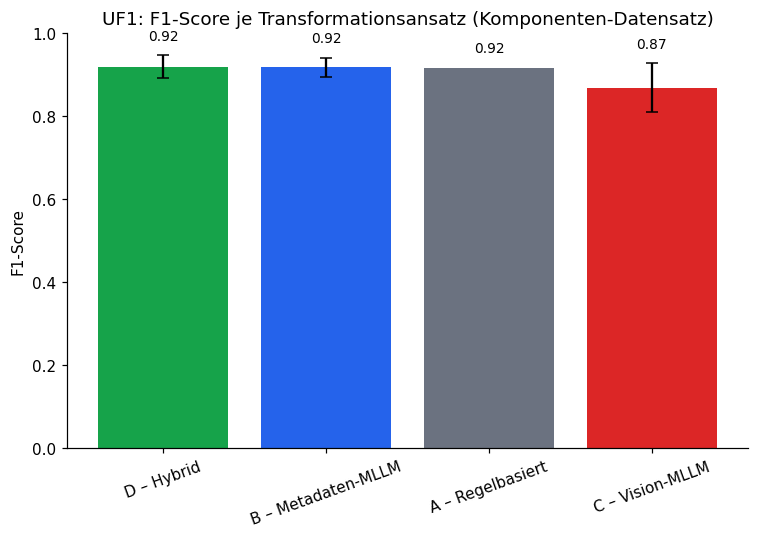

In [889]:
s = uf1['components']['summary']
fig, ax = plt.subplots(figsize=(7, 5))
if s is not None:
    ov = approach_overview(s)
    plot_single_metric_bar(ax, ov, 'f1_macro_mean', error_col='f1_macro_std')
ax.set_ylabel('F1-Score')
ax.set_ylim(0, 1)
ax.set_title('UF1: F1-Score je Transformationsansatz (Komponenten-Datensatz)')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'uf1_f1-score_je_ansatz_komponenten.png', dpi=150, bbox_inches='tight')
plt.show()

#### F1-Score (macro) per LLM model and approach

Only relevant for approaches B/C/D (approach A doesn't use an LLM). Shown
once for the components dataset, and once for the UI dataset split into
`pretty`/`messy` panels. 

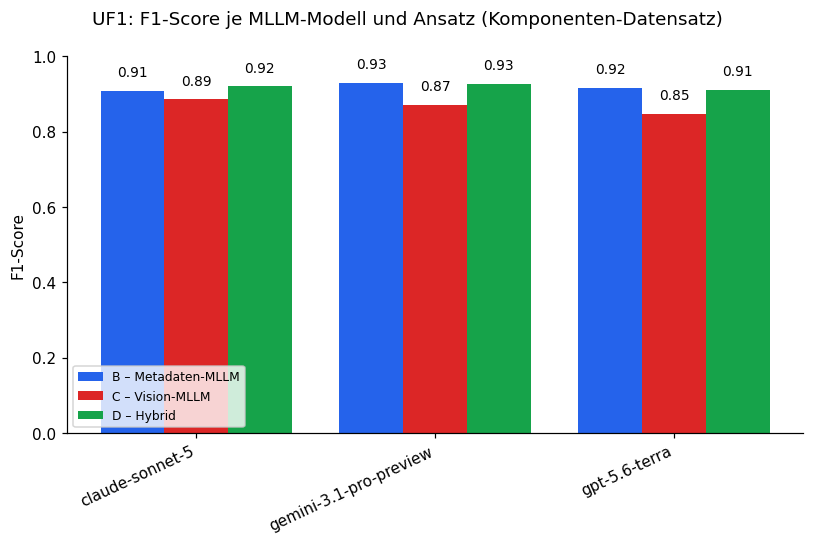

In [890]:
def model_breakdown(df: pd.DataFrame) -> pd.DataFrame:
    llm = df[df['approach'] != 'a'].copy()
    return llm.groupby(['approach', 'model'], dropna=False)['f1_macro'].mean().reset_index()


def plot_model_breakdown(ax, mb: pd.DataFrame, metric_col: str, ylabel: str):
    if mb.empty:
        ax.set_visible(False)
        return
    approaches = sorted(mb['approach'].unique())
    models = sorted(mb['model'].unique())
    x = np.arange(len(models))
    width = 0.8 / max(len(approaches), 1)
    for i, a in enumerate(approaches):
        sub = mb[mb['approach'] == a].set_index('model').reindex(models)
        bars = ax.bar(x + i * width, sub[metric_col], width, label=approach_label_de(a),
                       color=APPROACH_COLORS.get(a, '#999'))
        style_bars_with_values(ax, bars, sub[metric_col])
    ax.set_xticks(x + width * (len(approaches) - 1) / 2)
    ax.set_xticklabels(models, rotation=25, ha='right')
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 1)


s = uf1['components']['summary']
fig, ax = plt.subplots(figsize=(7.5, 5))
if s is not None:
    plot_model_breakdown(ax, model_breakdown(s), 'f1_macro', 'F1-Score')
ax.legend(loc='lower left', fontsize=8)
fig.suptitle('UF1: F1-Score je MLLM-Modell und Ansatz (Komponenten-Datensatz)')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'uf1_f1-score_je_mllm-modell_und_ansatz_komponenten.png', dpi=150, bbox_inches='tight')
plt.show()

UI dataset, split into `pretty`/`messy` (not compared to components).

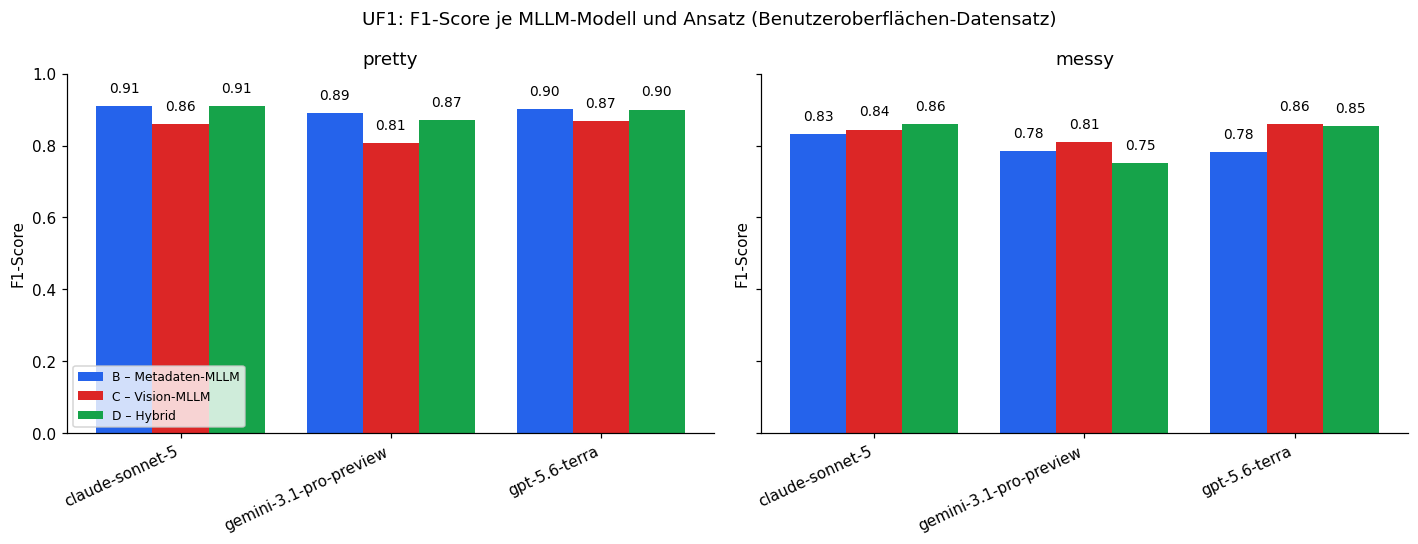

In [891]:
bg = uf1['uis']['by_group']
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, variant in zip(axes, ['pretty', 'messy']):
    sub = variant_df(bg, variant)
    if sub is None:
        ax.set_visible(False)
        continue
    plot_model_breakdown(ax, model_breakdown(sub), 'f1_macro', 'F1-Score')
    ax.set_title(variant)

axes[0].legend(loc='lower left', fontsize=8)
fig.suptitle('UF1: F1-Score je MLLM-Modell und Ansatz (Benutzeroberfl\u00e4chen-Datensatz)')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'uf1_f1-score_je_mllm-modell_und_ansatz_benutzeroberflaechen.png', dpi=150, bbox_inches='tight')
plt.show()

#### F1-Score (macro) per context strategy and approach

Only relevant for approaches B/C/D. The context strategy controls how much
PrimeVue documentation the model received while generating: **1** = none,
**2** = raw (unprocessed) docs for the components detected in the mockup,
**3** = cleaned/condensed docs for the same components (identical numbering
across B/C/D, see `build_context()` in the respective
`method-{b,c,d}-implementation.ipynb`).

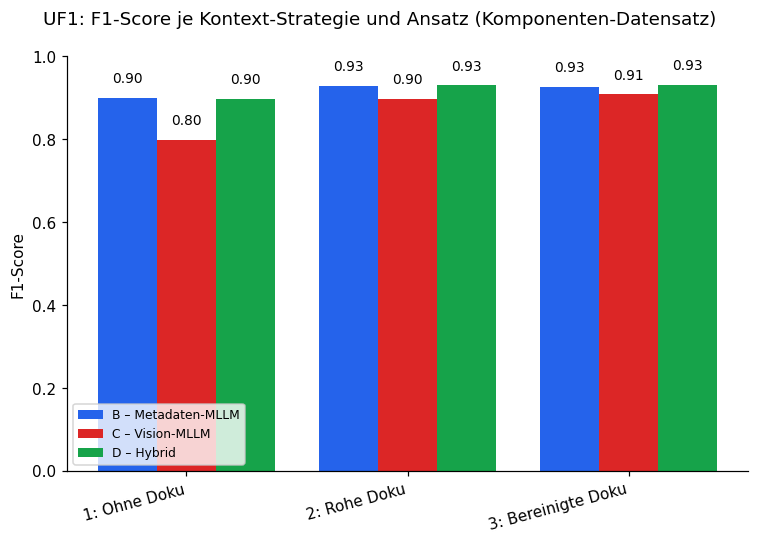

In [892]:
s = uf1['components']['summary']
fig, ax = plt.subplots(figsize=(7, 5))
if s is not None:
    plot_context_strategy_breakdown(ax, context_strategy_breakdown(s, 'f1_macro'), 'f1_macro', 'F1-Score')
ax.legend(loc='lower left', fontsize=8)
fig.suptitle('UF1: F1-Score je Kontext-Strategie und Ansatz (Komponenten-Datensatz)')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'uf1_f1-score_je_kontext-strategie_und_ansatz_komponenten.png', dpi=150, bbox_inches='tight')
plt.show()

UI dataset, split into `pretty`/`messy`.

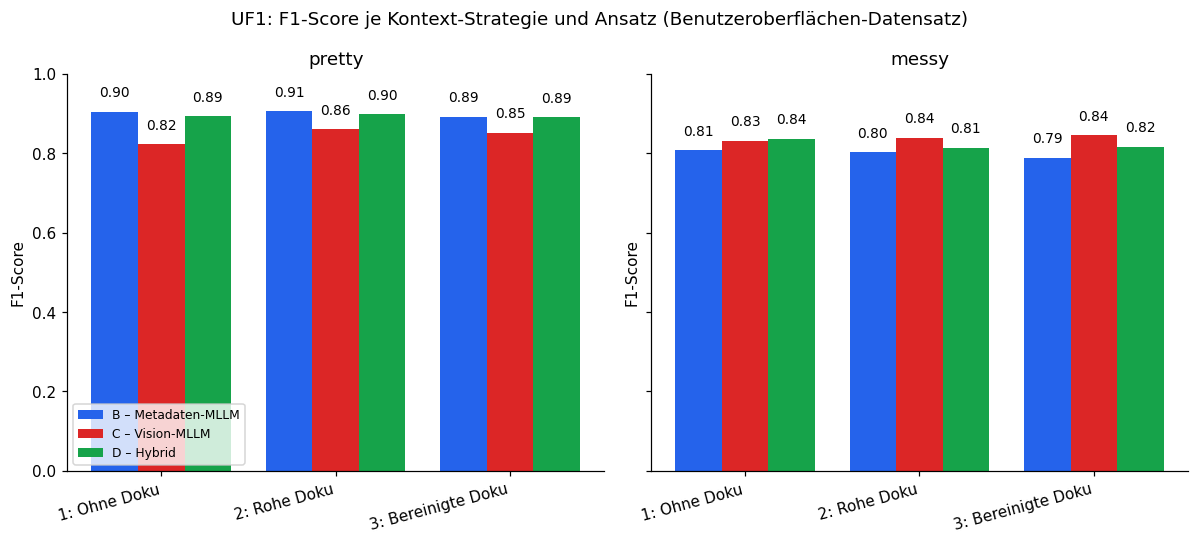

In [893]:
bg = uf1['uis']['by_group']
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)

for ax, variant in zip(axes, ['pretty', 'messy']):
    sub = variant_df(bg, variant)
    if sub is None:
        ax.set_visible(False)
        continue
    plot_context_strategy_breakdown(ax, context_strategy_breakdown(sub, 'f1_macro'), 'f1_macro', 'F1-Score')
    ax.set_title(variant)

axes[0].legend(loc='lower left', fontsize=8)
fig.suptitle('UF1: F1-Score je Kontext-Strategie und Ansatz (Benutzeroberfl\u00e4chen-Datensatz)')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'uf1_f1-score_je_kontext-strategie_und_ansatz_benutzeroberflaechen.png', dpi=150, bbox_inches='tight')
plt.show()

#### F1-Score (macro): Zero-Shot vs. Few-Shot

Only relevant for approaches B/C/D. Components dataset first, then the UI
dataset split into `pretty`/`messy` panels.

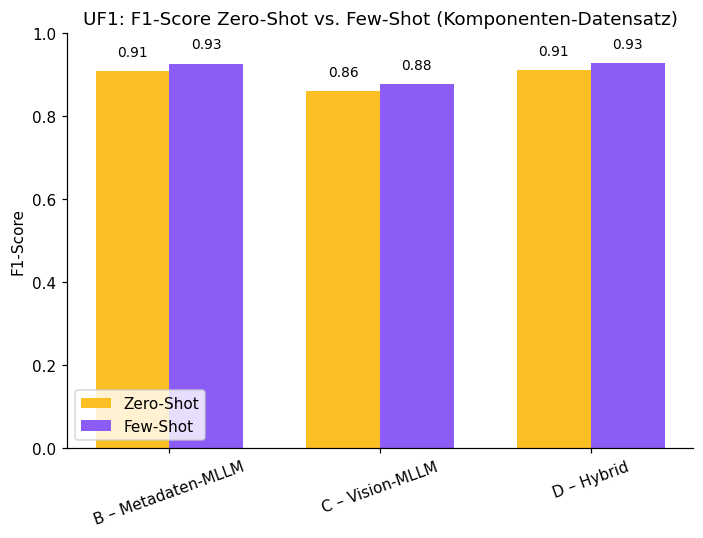

In [894]:
s = uf1['components']['summary']
fig, ax = plt.subplots(figsize=(6.5, 5))
if s is not None:
    plot_prompt_strategy_bar(ax, s, 'f1_macro')
ax.set_ylabel('F1-Score')
ax.set_ylim(0, 1)
ax.set_title('UF1: F1-Score Zero-Shot vs. Few-Shot (Komponenten-Datensatz)')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'uf1_f1-score_zero-shot_vs_few-shot_komponenten.png', dpi=150, bbox_inches='tight')
plt.show()

UI dataset, split into `pretty`/`messy`.

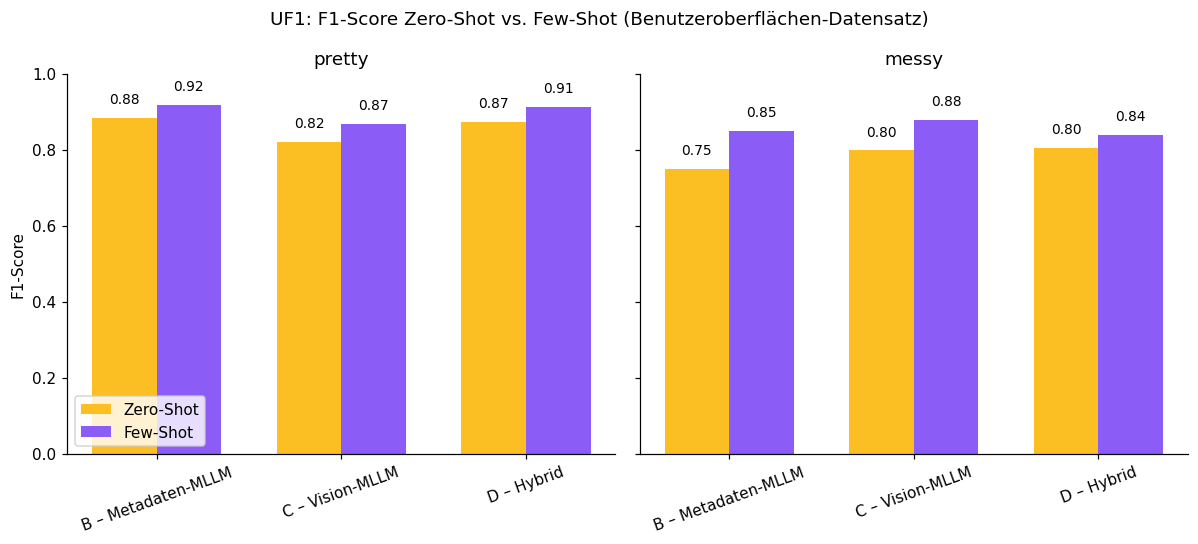

In [895]:
bg = uf1['uis']['by_group']
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)

for ax, variant in zip(axes, ['pretty', 'messy']):
    sub = variant_df(bg, variant)
    if sub is None:
        ax.set_visible(False)
        continue
    plot_prompt_strategy_bar(ax, sub, 'f1_macro')
    ax.set_title(variant)

axes[0].set_ylabel('F1-Score')
axes[0].set_ylim(0, 1)
axes[1].legend().remove()
fig.suptitle('UF1: F1-Score Zero-Shot vs. Few-Shot (Benutzeroberfl\u00e4chen-Datensatz)')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'uf1_f1-score_zero-shot_vs_few-shot_benutzeroberflaechen.png', dpi=150, bbox_inches='tight')
plt.show()

#### F1-Score by complexity level (components dataset)

Trend of the F1-macro score across `simple` → `medium` → `hard`. A flat curve
indicates high robustness against increasing mockup complexity (cf. UF5 /
degradation factor).

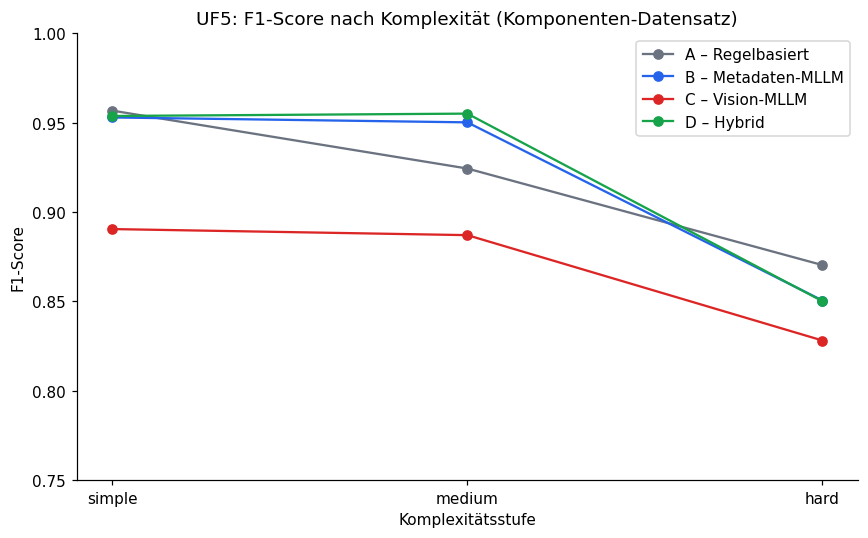

In [896]:
bg = uf1['components']['by_group']
if bg is not None:
    order = ['simple', 'medium', 'hard']
    fig, ax = plt.subplots(figsize=(8, 5))
    for a, sub in bg.groupby('approach'):
        agg = sub.groupby('complexity')['f1_macro'].mean().reindex(order)
        ax.plot(order, agg.values, marker='o', label=approach_label_de(a),
                color=APPROACH_COLORS.get(a, '#999'))
    ax.set_ylim(0.75, 1)
    ax.set_ylabel('F1-Score')
    ax.set_xlabel('Komplexitätsstufe')
    ax.set_title('UF5: F1-Score nach Komplexität (Komponenten-Datensatz)')
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / 'uf5_f1-score_nach_komplexitaet.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Skipped: eval_f1_components_by_complexity.csv not found.')

#### F1-Score: Pretty vs. Messy (UI dataset)

Compares result quality on cleanly structured (`pretty`) vs. unstructured
(`messy`) Figma mockups — the UI-dataset equivalent of the complexity levels
above (cf. UF5 / robustness index).

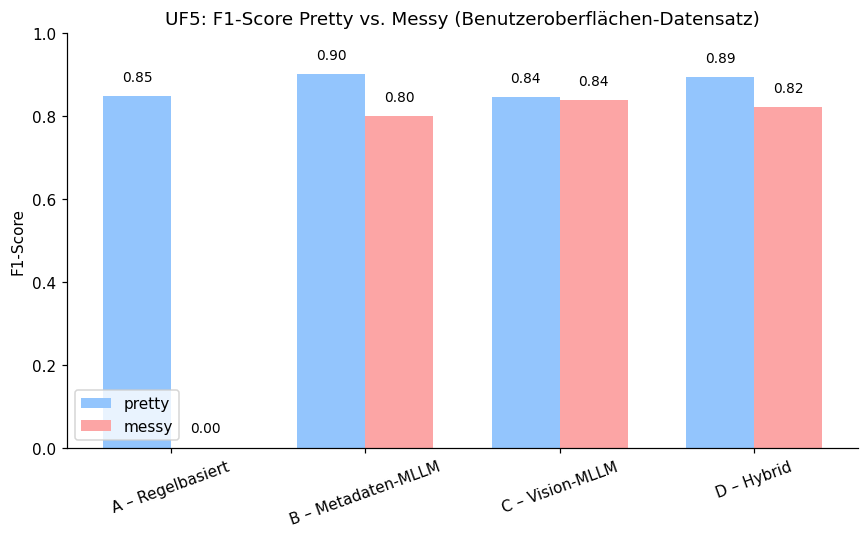

In [897]:
bg_uis = uf1['uis']['by_group']
fig, ax = plt.subplots(figsize=(8, 5))
plot_pretty_messy_bar(ax, bg_uis, 'f1_macro', legend_loc='lower left')
ax.set_ylabel('F1-Score')
ax.set_ylim(0, 1)
ax.set_title('UF5: F1-Score Pretty vs. Messy (Benutzeroberfl\u00e4chen-Datensatz)')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'uf5_f1-score_pretty_vs_messy.png', dpi=150, bbox_inches='tight')
plt.show()

#### Precision vs. Recall per configuration

Shows whether an approach tends toward over-generation (low precision) or
missed components (low recall). Points above the diagonal have higher
precision than recall. Components dataset first, then the UI dataset split
into `pretty`/`messy`.

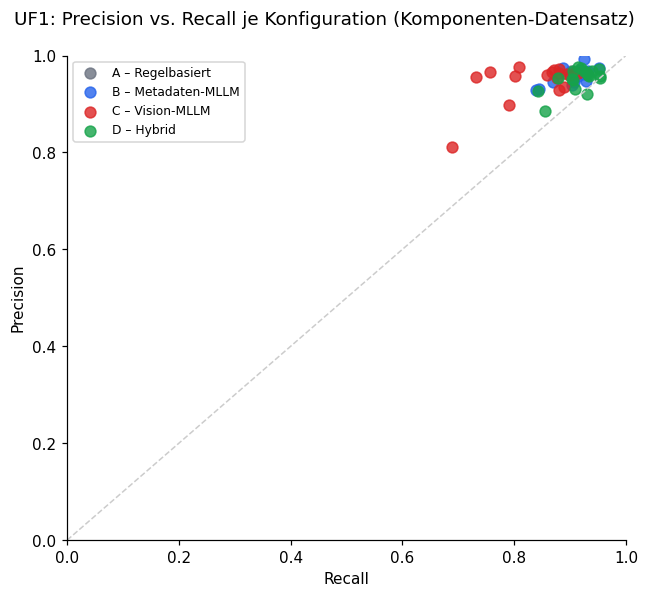

In [898]:
def plot_precision_recall(ax, df: pd.DataFrame, title: str):
    for a, sub in df.groupby('approach'):
        ax.scatter(sub['recall_macro'], sub['precision_macro'], label=approach_label_de(a),
                   color=APPROACH_COLORS.get(a, '#999'), alpha=0.8, s=50)
    ax.plot([0, 1], [0, 1], ls='--', color='#ccc', lw=1)
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_title(title)


s = uf1['components']['summary']
fig, ax = plt.subplots(figsize=(6, 5.5))
if s is not None:
    plot_precision_recall(ax, s, '')
ax.legend(fontsize=8)
fig.suptitle('UF1: Precision vs. Recall je Konfiguration (Komponenten-Datensatz)')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'uf1_precision-vs-recall_komponenten.png', dpi=150, bbox_inches='tight')
plt.show()

UI dataset, split into `pretty`/`messy`.

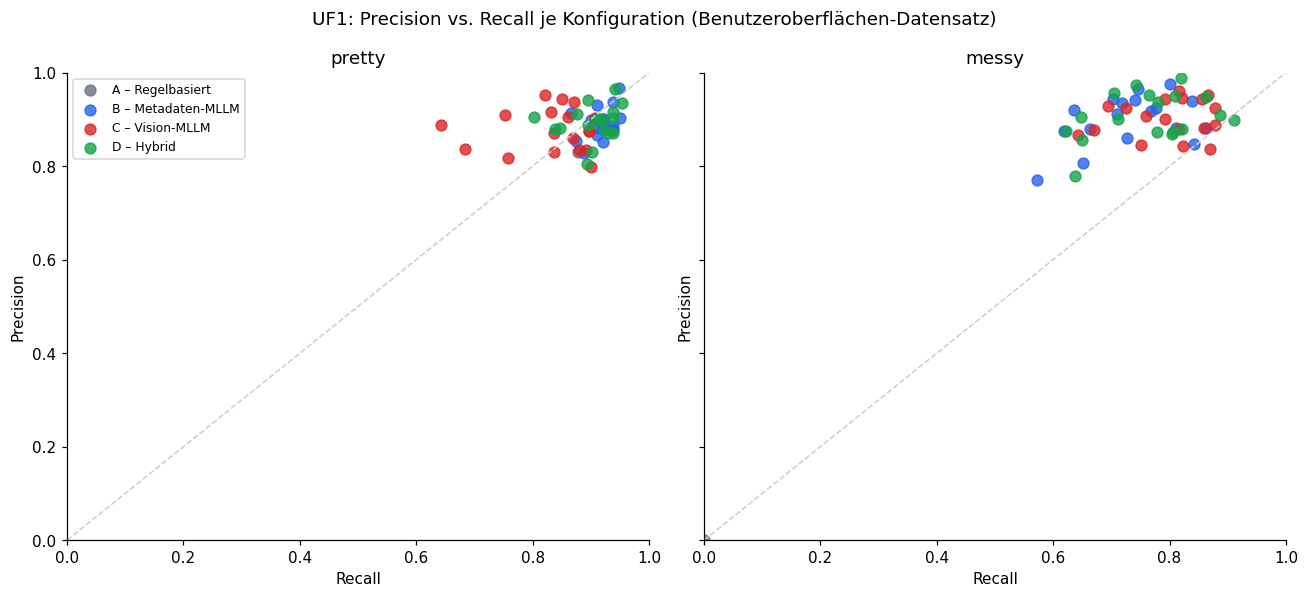

In [899]:
bg = uf1['uis']['by_group']
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), sharex=True, sharey=True)

for ax, variant in zip(axes, ['pretty', 'messy']):
    sub = variant_df(bg, variant)
    if sub is None or sub.empty:
        ax.set_visible(False)
        continue
    plot_precision_recall(ax, sub, variant)

axes[0].legend(fontsize=8)
fig.suptitle('UF1: Precision vs. Recall je Konfiguration (Benutzeroberfl\u00e4chen-Datensatz)')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'uf1_precision-vs-recall_benutzeroberflaechen.png', dpi=150, bbox_inches='tight')
plt.show()

#### Degradation / robustness factor per approach

`degradation_factor_hard = F1_hard / F1_simple` (components) resp.
`robustness_index = F1_messy / F1_pretty` (UI). Values close to 1 mean the
approach is robust against harder or messier inputs; values well below 1
indicate a strong dependence on clean structure / lower complexity.

In [900]:
deg = uf1['components'].get('degradation')
if deg is not None:
    print('--- Components dataset: degradation factor ---')
    deg_view = deg.copy()
    deg_view['approach_label'] = deg_view['approach'].map(approach_label)
    display(deg_view.groupby('approach_label')[
        ['f1_simple', 'f1_medium', 'f1_hard',
         'degradation_factor_medium', 'degradation_factor_hard']
    ].mean().round(3).sort_values('degradation_factor_hard', ascending=False))
else:
    print('Skipped: eval_f1_components_degradation.csv not found.')

rob = uf1['uis'].get('robustness')
if rob is not None:
    print('\n--- UI dataset: robustness index ---')
    rob_view = rob.copy()
    rob_view['approach_label'] = rob_view['approach'].map(approach_label)
    display(rob_view.groupby('approach_label')[
        ['f1_pretty', 'f1_messy', 'robustness_index']
    ].mean().round(3).sort_values('robustness_index', ascending=False))
else:
    print('Skipped: eval_f1_uis_robustness.csv not found.')

--- Components dataset: degradation factor ---


,f1_simple,f1_medium,f1_hard,degradation_factor_medium,degradation_factor_hard
approach_label,,,,,
C - Vision MLLM,0.890,0.887,0.828,0.997,0.932
A - Rule-based,0.957,0.924,0.870,0.966,0.910
B - Metadata MLLM,0.953,0.950,0.850,0.999,0.894
D - Hybrid,0.954,0.955,0.850,1.002,0.892



--- UI dataset: robustness index ---


,f1_pretty,f1_messy,robustness_index
approach_label,,,
C - Vision MLLM,0.845,0.838,0.993
D - Hybrid,0.893,0.822,0.920
B - Metadata MLLM,0.900,0.799,0.887
A - Rule-based,0.848,0.000,0.000


### 1.2 Component-Prop Accuracy

Share of props (per correctly identified component) whose name and value
match the ground truth, measures the *depth* of the mapping, not just
whether the right component tag was used.

Data source: `eval_prop_accuracy_{TYPE}_summary.csv`,
`eval_prop_accuracy_{TYPE}_by_complexity.csv`, and
`eval_prop_accuracy_{TYPE}_degradation.csv` (components) /
`eval_prop_accuracy_{TYPE}_robustness.csv` (uis) from
`evaluation_component_prop_accuracy.ipynb`.

In [901]:
def load_uf1_prop(type_: str) -> dict:
    d = EVAL_ROOT / type_
    data = {
        'summary':  load_csv(d / f'eval_prop_accuracy_{type_}_summary.csv'),
        'by_group': load_csv(d / f'eval_prop_accuracy_{type_}_by_complexity.csv'),
    }
    if type_ == 'components':
        data['degradation'] = load_csv(d / f'eval_prop_accuracy_{type_}_degradation.csv')
    else:
        data['robustness'] = load_csv(d / f'eval_prop_accuracy_{type_}_robustness.csv')
    return data


print('Loading UF1 data (Component-Prop Accuracy)...')
uf1_prop = {t: load_uf1_prop(t) for t in TYPES}

Loading UF1 data (Component-Prop Accuracy)...
  [loaded] evaluations\components\eval_prop_accuracy_components_summary.csv  (55 rows)
  [loaded] evaluations\components\eval_prop_accuracy_components_by_complexity.csv  (165 rows)
  [loaded] evaluations\components\eval_prop_accuracy_components_degradation.csv  (55 rows)
  [loaded] evaluations\uis\eval_prop_accuracy_uis_summary.csv  (55 rows)
  [loaded] evaluations\uis\eval_prop_accuracy_uis_by_complexity.csv  (110 rows)
  [loaded] evaluations\uis\eval_prop_accuracy_uis_robustness.csv  (55 rows)


#### Overview table per approach

Mean (± standard deviation) of prop-accuracy-macro and missing-rate-macro
across all strategies, models, and prompt strategies of a given method.
`missing_rate` is the share of expected props that are absent entirely
(neither correct nor wrong) — high accuracy with high missing rate means a
method under-specifies props rather than getting them wrong.

In [902]:
def prop_overview(summary: pd.DataFrame) -> pd.DataFrame:
    """Same shape as `approach_overview()` in section 1.1, but for the
    prop-accuracy metrics (prop_accuracy_macro/micro, missing_rate_macro/micro)
    instead of the F1 metrics."""
    g = summary.groupby('approach', dropna=False).agg(
        prop_accuracy_macro_mean=('prop_accuracy_macro', 'mean'),
        prop_accuracy_macro_std=('prop_accuracy_macro', 'std'),
        prop_accuracy_micro_mean=('prop_accuracy_micro', 'mean'),
        missing_rate_macro_mean=('missing_rate_macro', 'mean'),
        missing_rate_macro_std=('missing_rate_macro', 'std'),
        n_configs=('prop_accuracy_macro', 'size'),
    ).round(4).reset_index()
    g['approach_label'] = g['approach'].map(approach_label)
    cols = ['approach', 'approach_label', 'prop_accuracy_macro_mean', 'prop_accuracy_macro_std',
            'prop_accuracy_micro_mean', 'missing_rate_macro_mean', 'missing_rate_macro_std', 'n_configs']
    return g[cols].sort_values('prop_accuracy_macro_mean', ascending=False).reset_index(drop=True)


uf1_prop_overview_tables = {}

s = uf1_prop['components']['summary']
if s is not None:
    print('\n--- Overview: Components dataset ---')
    ov = prop_overview(s)
    uf1_prop_overview_tables['components'] = ov
    display(ov.drop(columns='approach'))

for variant in ['pretty', 'messy']:
    sub = variant_df(uf1_prop['uis']['by_group'], variant)
    if sub is None or sub.empty:
        continue
    print(f'\n--- Overview: UI dataset ({variant}) ---')
    ov = prop_overview(sub)
    uf1_prop_overview_tables[f'uis_{variant}'] = ov
    display(ov.drop(columns='approach'))


--- Overview: Components dataset ---


,approach_label,prop_accuracy_macro_mean,prop_accuracy_macro_std,prop_accuracy_micro_mean,missing_rate_macro_mean,missing_rate_macro_std,n_configs
0,A - Rule-based,0.5241,NaN,0.5042,0.6325,NaN,1
1,B - Metadata MLLM,0.5004,0.0873,0.4630,0.3683,0.0840,18
2,D - Hybrid,0.4772,0.0956,0.4496,0.3904,0.0858,18
3,C - Vision MLLM,0.4390,0.0861,0.4160,0.4290,0.0796,18



--- Overview: UI dataset (pretty) ---


,approach_label,prop_accuracy_macro_mean,prop_accuracy_macro_std,prop_accuracy_micro_mean,missing_rate_macro_mean,missing_rate_macro_std,n_configs
0,B - Metadata MLLM,0.4638,0.0667,0.4508,0.3350,0.0726,18
1,D - Hybrid,0.4584,0.0813,0.4452,0.3700,0.0767,18
2,C - Vision MLLM,0.4171,0.0871,0.4051,0.3969,0.0767,18
3,A - Rule-based,0.4071,NaN,0.4227,0.6210,NaN,1



--- Overview: UI dataset (messy) ---


,approach_label,prop_accuracy_macro_mean,prop_accuracy_macro_std,prop_accuracy_micro_mean,missing_rate_macro_mean,missing_rate_macro_std,n_configs
0,D - Hybrid,0.4319,0.0810,0.4209,0.3923,0.1057,18
1,C - Vision MLLM,0.4295,0.0737,0.4184,0.4012,0.1011,18
2,B - Metadata MLLM,0.3961,0.0710,0.3981,0.4158,0.0890,18
3,A - Rule-based,NaN,NaN,NaN,NaN,NaN,1


#### Prop Accuracy per approach — components dataset

The UI-dataset equivalent, split into `pretty`/`messy`, is the "Pretty vs.
Messy" chart further below.

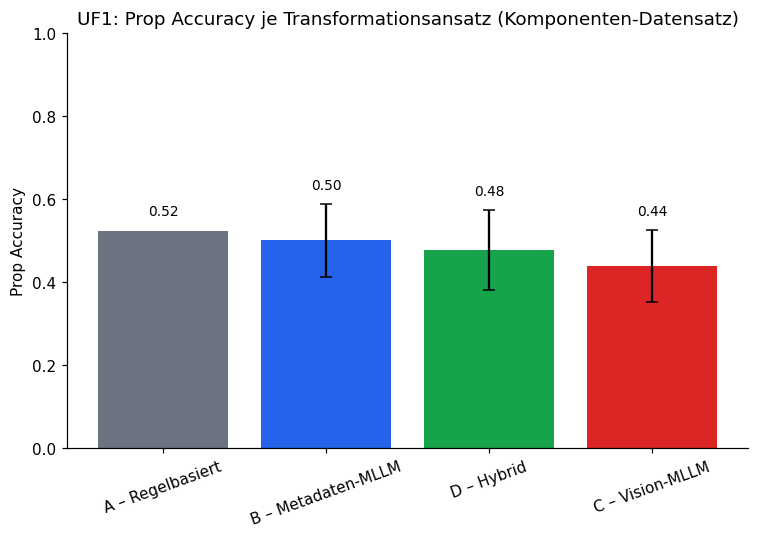

In [903]:
s = uf1_prop['components']['summary']
fig, ax = plt.subplots(figsize=(7, 5))
if s is not None:
    ov = prop_overview(s)
    plot_single_metric_bar(ax, ov, 'prop_accuracy_macro_mean', error_col='prop_accuracy_macro_std')
ax.set_ylabel('Prop Accuracy')
ax.set_ylim(0, 1)
ax.set_title('UF1: Prop Accuracy je Transformationsansatz (Komponenten-Datensatz)')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'uf1_prop-accuracy_je_ansatz_komponenten.png', dpi=150, bbox_inches='tight')
plt.show()

#### Missing Rate per approach

Share of expected props that are missing entirely from the generated code
(neither correct nor wrong). Components dataset first, then the UI dataset
split into `pretty`/`messy`.

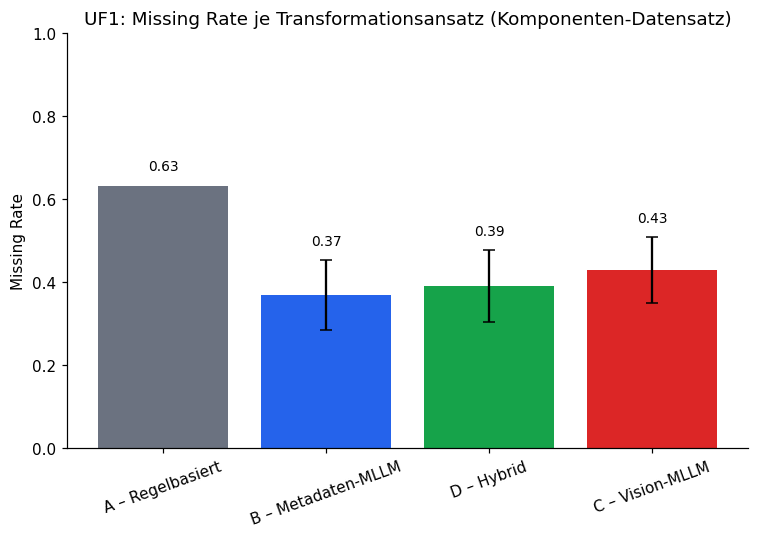

In [904]:
s = uf1_prop['components']['summary']
fig, ax = plt.subplots(figsize=(7, 5))
if s is not None:
    ov = prop_overview(s)
    plot_single_metric_bar(ax, ov, 'missing_rate_macro_mean', error_col='missing_rate_macro_std')
ax.set_ylabel('Missing Rate')
ax.set_ylim(0, 1)
ax.set_title('UF1: Missing Rate je Transformationsansatz (Komponenten-Datensatz)')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'uf1_missing-rate_je_ansatz_komponenten.png', dpi=150, bbox_inches='tight')
plt.show()

UI dataset, split into `pretty`/`messy`.

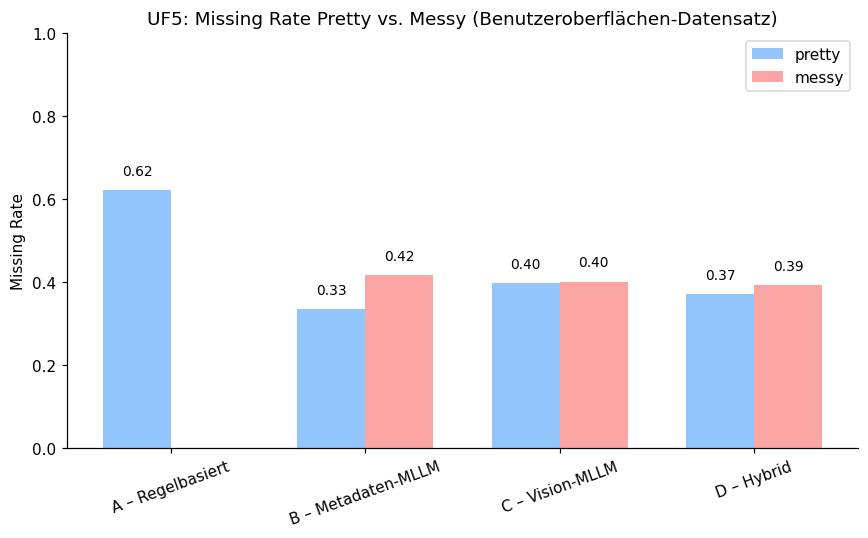

In [905]:
bg = uf1_prop['uis']['by_group']
fig, ax = plt.subplots(figsize=(8, 5))
plot_pretty_messy_bar(ax, bg, 'missing_rate_macro')
ax.set_ylabel('Missing Rate')
ax.set_ylim(0, 1)
ax.set_title('UF5: Missing Rate Pretty vs. Messy (Benutzeroberfl\u00e4chen-Datensatz)')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'uf5_missing-rate_pretty_vs_messy.png', dpi=150, bbox_inches='tight')
plt.show()

#### Prop Accuracy per LLM model and approach

Only relevant for approaches B/C/D. Components dataset, then UI dataset
split into `pretty`/`messy` panels.

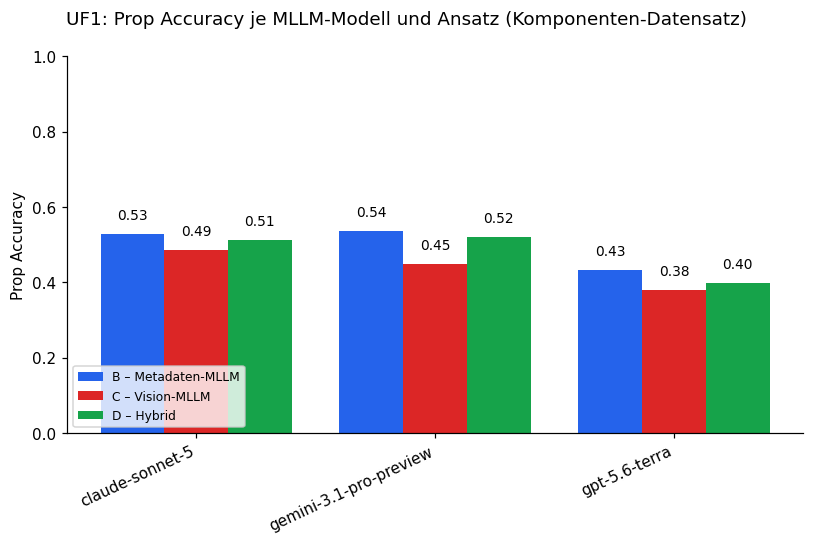

In [906]:
def model_breakdown_prop(df: pd.DataFrame) -> pd.DataFrame:
    llm = df[df['approach'] != 'a'].copy()
    return llm.groupby(['approach', 'model'], dropna=False)['prop_accuracy_macro'].mean().reset_index()


s = uf1_prop['components']['summary']
fig, ax = plt.subplots(figsize=(7.5, 5))
if s is not None:
    plot_model_breakdown(ax, model_breakdown_prop(s), 'prop_accuracy_macro', 'Prop Accuracy')
ax.legend(loc='lower left', fontsize=8)
fig.suptitle('UF1: Prop Accuracy je MLLM-Modell und Ansatz (Komponenten-Datensatz)')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'uf1_prop-accuracy_je_mllm-modell_und_ansatz_komponenten.png', dpi=150, bbox_inches='tight')
plt.show()

UI dataset, split into `pretty`/`messy`.

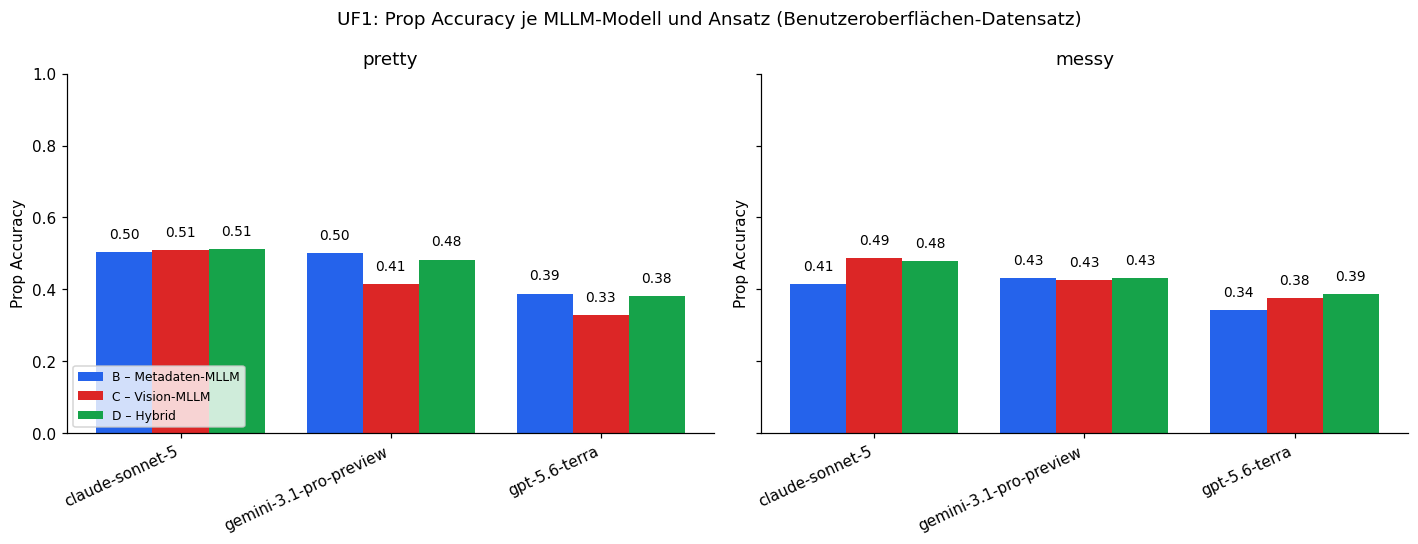

In [907]:
bg = uf1_prop['uis']['by_group']
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, variant in zip(axes, ['pretty', 'messy']):
    sub = variant_df(bg, variant)
    if sub is None:
        ax.set_visible(False)
        continue
    plot_model_breakdown(ax, model_breakdown_prop(sub), 'prop_accuracy_macro', 'Prop Accuracy')
    ax.set_title(variant)

axes[0].legend(loc='lower left', fontsize=8)
fig.suptitle('UF1: Prop Accuracy je MLLM-Modell und Ansatz (Benutzeroberfl\u00e4chen-Datensatz)')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'uf1_prop-accuracy_je_mllm-modell_und_ansatz_benutzeroberflaechen.png', dpi=150, bbox_inches='tight')
plt.show()

#### Prop Accuracy per context strategy and approach

Only relevant for approaches B/C/D. Same context-strategy numbering as for
F1-Score above: **1** = no documentation, **2** = raw docs, **3** =
cleaned/condensed docs.

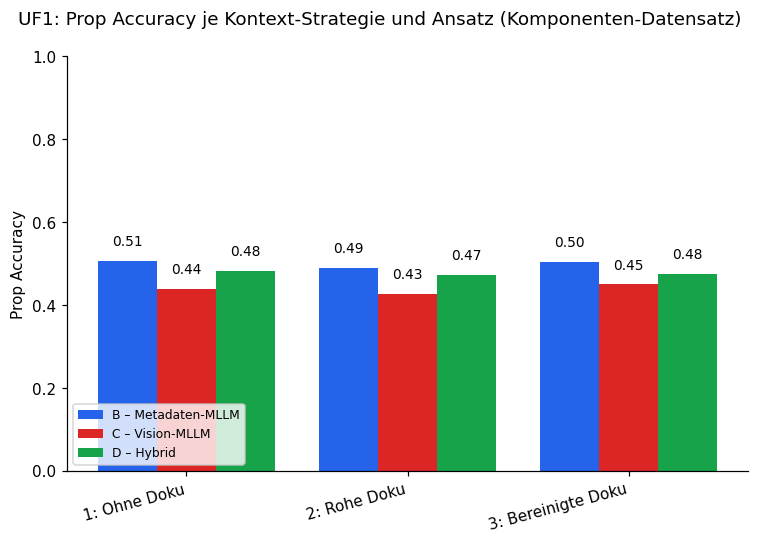

In [908]:
s = uf1_prop['components']['summary']
fig, ax = plt.subplots(figsize=(7, 5))
if s is not None:
    plot_context_strategy_breakdown(ax, context_strategy_breakdown(s, 'prop_accuracy_macro'),
                                     'prop_accuracy_macro', 'Prop Accuracy')
ax.legend(loc='lower left', fontsize=8)
fig.suptitle('UF1: Prop Accuracy je Kontext-Strategie und Ansatz (Komponenten-Datensatz)')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'uf1_prop-accuracy_je_kontext-strategie_und_ansatz_komponenten.png', dpi=150, bbox_inches='tight')
plt.show()

UI dataset, split into `pretty`/`messy`.

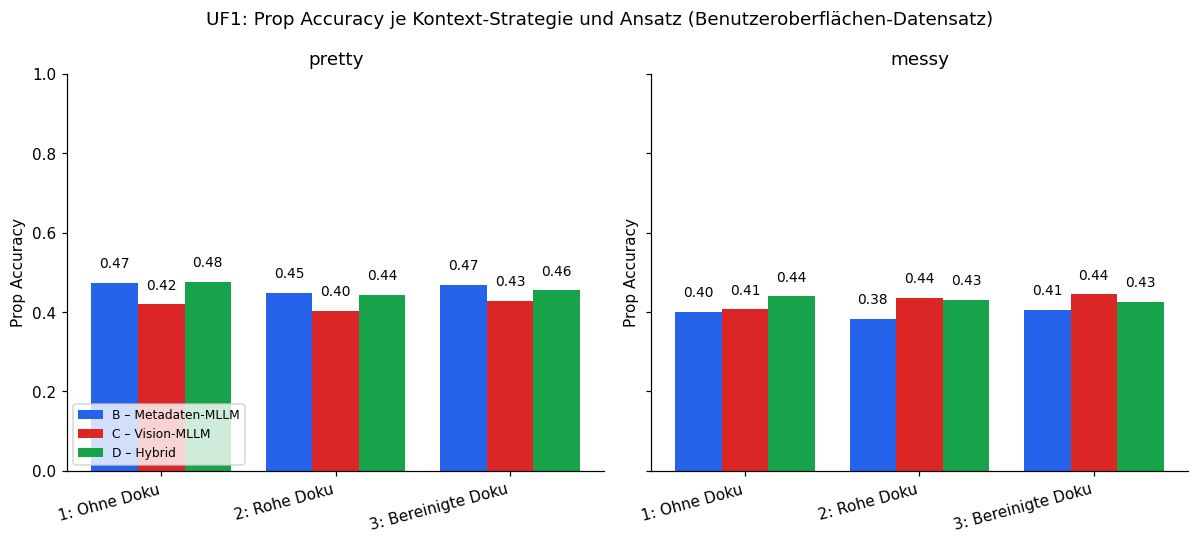

In [909]:
bg = uf1_prop['uis']['by_group']
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)

for ax, variant in zip(axes, ['pretty', 'messy']):
    sub = variant_df(bg, variant)
    if sub is None:
        ax.set_visible(False)
        continue
    plot_context_strategy_breakdown(ax, context_strategy_breakdown(sub, 'prop_accuracy_macro'),
                                     'prop_accuracy_macro', 'Prop Accuracy')
    ax.set_title(variant)

axes[0].legend(loc='lower left', fontsize=8)
fig.suptitle('UF1: Prop Accuracy je Kontext-Strategie und Ansatz (Benutzeroberfl\u00e4chen-Datensatz)')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'uf1_prop-accuracy_je_kontext-strategie_und_ansatz_benutzeroberflaechen.png', dpi=150, bbox_inches='tight')
plt.show()

#### Prop Accuracy by complexity level (components dataset)

*(Chart text in German; the level names `simple`/`medium`/`hard` are
technical dataset labels and stay untranslated, matching `evaluation.md`.)*

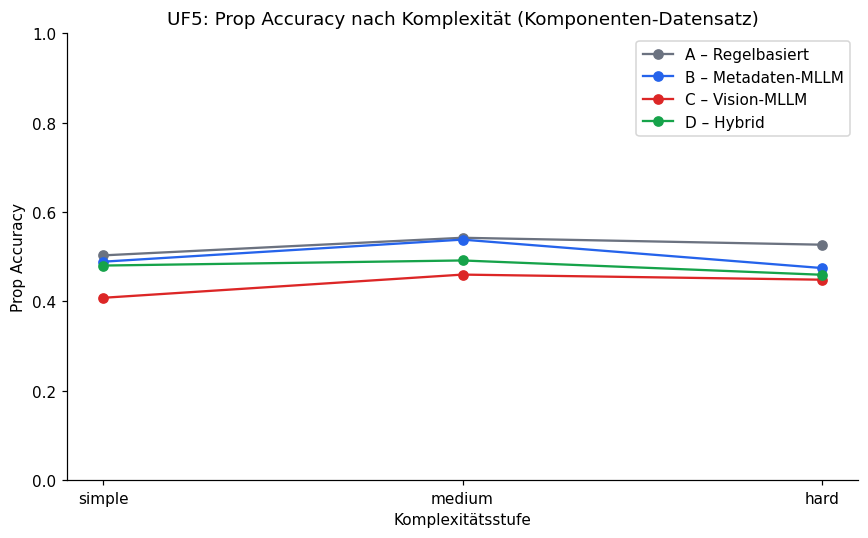

In [910]:
bg_prop = uf1_prop['components']['by_group']
if bg_prop is not None:
    order = ['simple', 'medium', 'hard']
    fig, ax = plt.subplots(figsize=(8, 5))
    for a, sub in bg_prop.groupby('approach'):
        agg = sub.groupby('complexity')['prop_accuracy_macro'].mean().reindex(order)
        ax.plot(order, agg.values, marker='o', label=approach_label_de(a),
                color=APPROACH_COLORS.get(a, '#999'))
    ax.set_ylim(0, 1)
    ax.set_ylabel('Prop Accuracy')
    ax.set_xlabel('Komplexit\u00e4tsstufe')
    ax.set_title('UF5: Prop Accuracy nach Komplexit\u00e4t (Komponenten-Datensatz)')
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / 'uf5_prop-accuracy_nach_komplexitaet.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Skipped: eval_prop_accuracy_components_by_complexity.csv not found.')

#### Prop Accuracy: Pretty vs. Messy (UI dataset)

Approach A has no bar for
`messy`, since it had zero correctly-matched components there —> see the UF1
F1-Score section, so no prop accuracy could be computed.

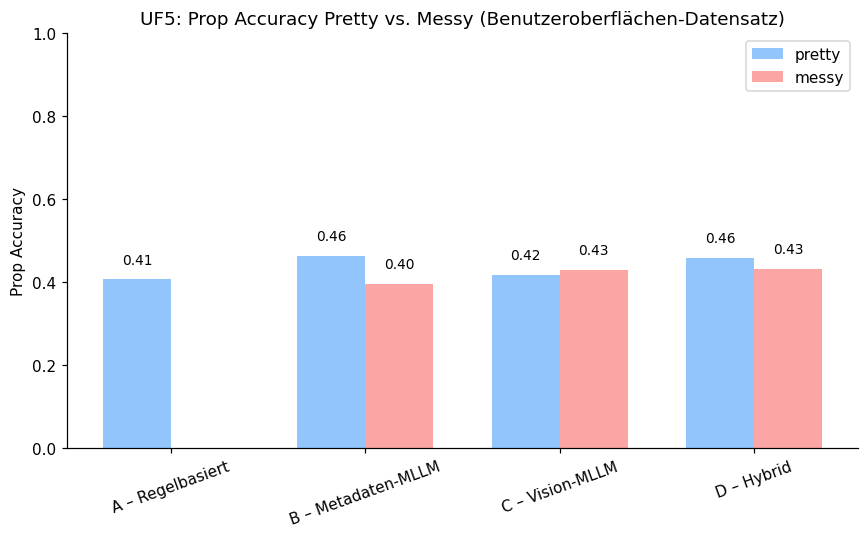

In [911]:
bg_uis_prop = uf1_prop['uis']['by_group']
fig, ax = plt.subplots(figsize=(8, 5))
plot_pretty_messy_bar(ax, bg_uis_prop, 'prop_accuracy_macro')
ax.set_ylabel('Prop Accuracy')
ax.set_ylim(0, 1)
ax.set_title('UF5: Prop Accuracy Pretty vs. Messy (Benutzeroberfl\u00e4chen-Datensatz)')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'uf5_prop-accuracy_pretty_vs_messy.png', dpi=150, bbox_inches='tight')
plt.show()

#### Degradation / robustness factor per approach

`degradation_factor_hard = PropAcc_hard / PropAcc_simple` (components) resp.
`robustness_index = PropAcc_messy / PropAcc_pretty` (UI). Approach A has no
robustness index for the UI dataset, since it produced zero correctly-matched
components on `messy` mockups (see UF1 F1-Score section), there's nothing to
compute prop accuracy on.

In [912]:
deg_prop = uf1_prop['components'].get('degradation')
if deg_prop is not None:
    print('--- Components dataset: degradation factor ---')
    deg_view = deg_prop.copy()
    deg_view['approach_label'] = deg_view['approach'].map(approach_label)
    display(deg_view.groupby('approach_label')[
        ['prop_accuracy_simple', 'prop_accuracy_medium', 'prop_accuracy_hard',
         'degradation_factor_medium', 'degradation_factor_hard']
    ].mean().round(3).sort_values('degradation_factor_hard', ascending=False))
else:
    print('Skipped: eval_prop_accuracy_components_degradation.csv not found.')

rob_prop = uf1_prop['uis'].get('robustness')
if rob_prop is not None:
    print('\n--- UI dataset: robustness index ---')
    rob_view = rob_prop.copy()
    rob_view['approach_label'] = rob_view['approach'].map(approach_label)
    display(rob_view.groupby('approach_label')[
        ['prop_accuracy_pretty', 'prop_accuracy_messy', 'robustness_index']
    ].mean().round(3).sort_values('robustness_index', ascending=False))
else:
    print('Skipped: eval_prop_accuracy_uis_robustness.csv not found.')

--- Components dataset: degradation factor ---


,prop_accuracy_simple,prop_accuracy_medium,prop_accuracy_hard,degradation_factor_medium,degradation_factor_hard
approach_label,,,,,
C - Vision MLLM,0.408,0.460,0.448,1.159,1.119
A - Rule-based,0.503,0.542,0.527,1.078,1.048
B - Metadata MLLM,0.489,0.538,0.475,1.134,0.975
D - Hybrid,0.480,0.492,0.460,1.039,0.956



--- UI dataset: robustness index ---


,prop_accuracy_pretty,prop_accuracy_messy,robustness_index
approach_label,,,
C - Vision MLLM,0.417,0.430,1.044
D - Hybrid,0.458,0.432,0.951
B - Metadata MLLM,0.464,0.396,0.856
A - Rule-based,0.407,NaN,NaN


## UF2: Code Quality

> *"To what extent do the generated results meet PrimeVue API conventions
> [...] as well as general code maintainability criteria?"*

Data source: `eval_code_quality_maintainability_{TYPE}_summary.csv`,
`eval_code_quality_maintainability_{TYPE}_by_complexity.csv`, and
`eval_code_quality_maintainability_{TYPE}_degradation.csv` (components) /
`eval_code_quality_maintainability_{TYPE}_robustness.csv` (uis) from
`evaluation_code_quality_maintainability.ipynb`.

Metrics span five stages (per `evaluation.md`):

| Stage | Metric | Column(s) |
|---|---|---|
| 0 — Structural integrity | Parse-OK-Rate | `parse_ok_rate` |
| 1 — Technical correctness | Compile Success Rate | `compile_success_rate` |
| 2 — Completeness | Import Completeness | `import_completeness_macro` |
| 3 — Framework conformance | PrimeVue API conformance (4 sub-metrics) | `prop_validity_rate_micro`, `slot_correctness_micro`, `binding_correctness_micro`, `pt_correctness_micro` |
| 4 — Maintainability | Arbitrary Value Usage, Code Duplication Rate, Comment Density, LOC Ratio | `avu_macro`, `cdr_macro`, `cd_macro`, `loc_ratio_macro` |

Stage 3's four sub-metrics are self-consistency checks against the PrimeVue
API (independent of whether the component was even the right one to
generate — that's UF1's job) and are kept separate per `evaluation.md`, since
they measure different things (existence, structure, binding kind, extension
mechanism). A combined "at a glance" average is shown alongside them but
shouldn't be over-interpreted on its own.

In [913]:
def load_uf2(type_: str) -> dict:
    d = EVAL_ROOT / type_
    data = {
        'summary':  load_csv(d / f'eval_code_quality_maintainability_{type_}_summary.csv'),
        'by_group': load_csv(d / f'eval_code_quality_maintainability_{type_}_by_complexity.csv'),
    }
    if type_ == 'components':
        data['degradation'] = load_csv(d / f'eval_code_quality_maintainability_{type_}_degradation.csv')
    else:
        data['robustness'] = load_csv(d / f'eval_code_quality_maintainability_{type_}_robustness.csv')
    return data


print('Loading UF2 data (Code Quality & Maintainability)...')
uf2 = {t: load_uf2(t) for t in TYPES}

Loading UF2 data (Code Quality & Maintainability)...
  [loaded] evaluations\components\eval_code_quality_maintainability_components_summary.csv  (55 rows)
  [loaded] evaluations\components\eval_code_quality_maintainability_components_by_complexity.csv  (165 rows)
  [loaded] evaluations\components\eval_code_quality_maintainability_components_degradation.csv  (55 rows)
  [loaded] evaluations\uis\eval_code_quality_maintainability_uis_summary.csv  (55 rows)
  [loaded] evaluations\uis\eval_code_quality_maintainability_uis_by_complexity.csv  (110 rows)
  [loaded] evaluations\uis\eval_code_quality_maintainability_uis_robustness.csv  (55 rows)


### Overview tables per approach

Mean across all strategies, models, and prompt strategies of a given method.
Split into the three stage groups for readability, and for the UI
dataset into `pretty`/`messy` instead of a blended average. `NaN` means
the metric was undefined for every configuration of that approach (e.g.
`pt_correctness` for approach A, which never uses PrimeVue's `pt` passthrough
mechanism).

In [914]:
def code_quality_overview(df: pd.DataFrame) -> pd.DataFrame:
    g = df.groupby('approach', dropna=False).agg(
        parse_ok_rate=('parse_ok_rate', 'mean'),
        compile_success_rate=('compile_success_rate', 'mean'),
        import_completeness=('import_completeness_macro', 'mean'),
        prop_validity_rate=('prop_validity_rate_micro', 'mean'),
        slot_correctness=('slot_correctness_micro', 'mean'),
        binding_correctness=('binding_correctness_micro', 'mean'),
        pt_correctness=('pt_correctness_micro', 'mean'),
        avu=('avu_macro', 'mean'),
        cdr=('cdr_macro', 'mean'),
        cd=('cd_macro', 'mean'),
        loc_ratio=('loc_ratio_macro', 'mean'),
        n_configs=('parse_ok_rate', 'size'),
    ).round(4).reset_index()
    g['approach_label'] = g['approach'].map(approach_label)
    # at-a-glance average of the four Stage-3 API-conformance sub-metrics;
    # approximation from already-aggregated summary columns (mean of means),
    # not a re-derivation from per-mockup data -- fine for a quick overview,
    # per evaluation.md the four sub-metrics remain the metrics of record.
    g['api_conformance_avg'] = g[['prop_validity_rate', 'slot_correctness',
                                   'binding_correctness', 'pt_correctness']].mean(axis=1, skipna=True)
    return g.sort_values('parse_ok_rate', ascending=False).reset_index(drop=True)


uf2_overview_tables = {}
stage012_cols = ['approach_label', 'parse_ok_rate', 'compile_success_rate', 'import_completeness']
stage3_cols = ['approach_label', 'prop_validity_rate', 'slot_correctness', 'binding_correctness',
               'pt_correctness', 'api_conformance_avg']
stage4_cols = ['approach_label', 'avu', 'cdr', 'cd', 'loc_ratio']


def show_code_quality_tables(df: pd.DataFrame, label: str, key: str):
    ov = code_quality_overview(df)
    uf2_overview_tables[key] = ov
    print(f'\n--- {label}: Stage 0-2 (structure, compile, imports) ---')
    display(ov[stage012_cols])
    print(f'--- {label}: Stage 3 (PrimeVue API conformance) ---')
    display(ov[stage3_cols])
    print(f'--- {label}: Stage 4 (maintainability) ---')
    display(ov[stage4_cols])


s = uf2['components']['summary']
if s is not None:
    show_code_quality_tables(s, 'Components dataset', 'components')

for variant in ['pretty', 'messy']:
    sub = variant_df(uf2['uis']['by_group'], variant)
    if sub is None or sub.empty:
        continue
    show_code_quality_tables(sub, f'UI dataset ({variant})', f'uis_{variant}')


--- Components dataset: Stage 0-2 (structure, compile, imports) ---


,approach_label,parse_ok_rate,compile_success_rate,import_completeness
0,A - Rule-based,1.0000,1.0000,1.0
1,C - Vision MLLM,1.0000,0.9741,1.0
2,D - Hybrid,1.0000,0.9815,1.0
3,B - Metadata MLLM,0.9981,0.9722,1.0


--- Components dataset: Stage 3 (PrimeVue API conformance) ---


,approach_label,prop_validity_rate,slot_correctness,binding_correctness,pt_correctness,api_conformance_avg
0,A - Rule-based,0.8505,1.0000,0.8359,NaN,0.895467
1,C - Vision MLLM,0.7901,0.9901,0.7852,0.9278,0.873300
2,D - Hybrid,0.7815,0.9972,0.7798,0.9728,0.882825
3,B - Metadata MLLM,0.7704,0.9969,0.7694,0.9924,0.882275


--- Components dataset: Stage 4 (maintainability) ---


...

,approach_label,parse_ok_rate,compile_success_rate,import_completeness
0,A - Rule-based,1.0,1.0000,NaN
1,B - Metadata MLLM,1.0,0.9333,1.0
2,C - Vision MLLM,1.0,0.9222,1.0
3,D - Hybrid,1.0,0.9000,1.0


--- UI dataset (messy): Stage 3 (PrimeVue API conformance) ---


,approach_label,prop_validity_rate,slot_correctness,binding_correctness,pt_correctness,api_conformance_avg
0,A - Rule-based,NaN,NaN,NaN,NaN,NaN
1,B - Metadata MLLM,0.7920,1.0000,0.7552,0.9849,0.883025
2,C - Vision MLLM,0.8491,0.9938,0.7301,0.8750,0.862000
3,D - Hybrid,0.8303,1.0000,0.7366,0.9705,0.884350


--- UI dataset (messy): Stage 4 (maintainability) ---


,approach_label,avu,cdr,cd,loc_ratio
0,A - Rule-based,0.0000,0.4413,0.0000,0.8222
1,B - Metadata MLLM,0.0686,0.0780,0.0237,0.9290
2,C - Vision MLLM,0.0408,0.0746,0.0207,0.8684
3,D - Hybrid,0.0498,0.0737,0.0199,0.9351


#### Stage 0–2: Structural integrity, compilation & imports

Grouped by metric, with one bar per approach. Components dataset first, then
the UI dataset split into `pretty`/`messy` panels.

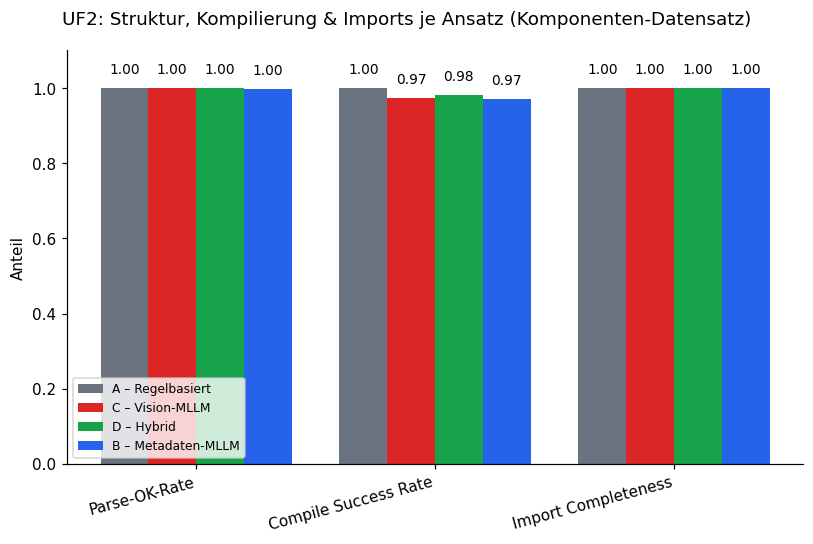

In [915]:
stage012_metrics = [
    ('parse_ok_rate', 'Parse-OK-Rate'),
    ('compile_success_rate', 'Compile Success Rate'),
    ('import_completeness', 'Import Completeness'),
]

s = uf2['components']['summary']
fig, ax = plt.subplots(figsize=(7.5, 5))
if s is not None:
    ov = code_quality_overview(s)
    plot_metric_group_bar(ax, ov, stage012_metrics)
ax.set_ylabel('Anteil')
ax.set_ylim(0, 1.1)
ax.legend(loc='lower left', fontsize=8)
fig.suptitle('UF2: Struktur, Kompilierung & Imports je Ansatz (Komponenten-Datensatz)')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'uf2_struktur-kompilierung-imports_je_ansatz_komponenten.png', dpi=150, bbox_inches='tight')
plt.show()

UI dataset, split into `pretty`/`messy`.

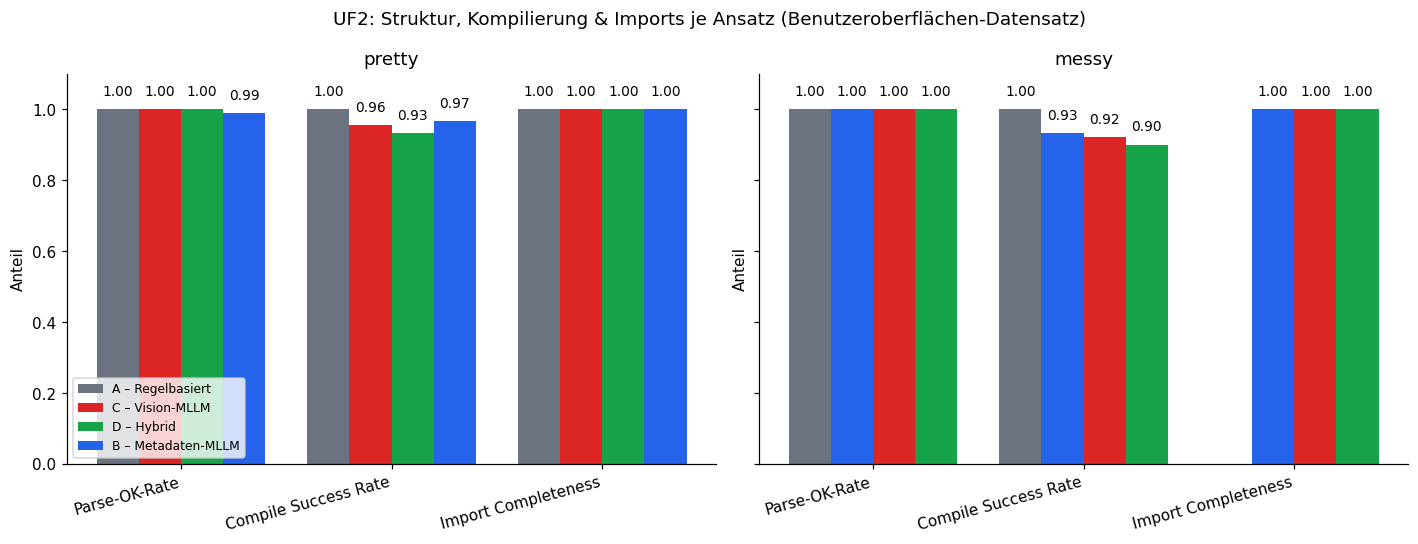

In [916]:
bg = uf2['uis']['by_group']
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, variant in zip(axes, ['pretty', 'messy']):
    sub = variant_df(bg, variant)
    if sub is None or sub.empty:
        ax.set_visible(False)
        continue
    ov = code_quality_overview(sub)
    plot_metric_group_bar(ax, ov, stage012_metrics)
    ax.set_ylabel('Anteil')
    ax.set_ylim(0, 1.1)
    ax.set_title(variant)

axes[0].legend(loc='lower left', fontsize=8)
fig.suptitle('UF2: Struktur, Kompilierung & Imports je Ansatz (Benutzeroberfl\u00e4chen-Datensatz)')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'uf2_struktur-kompilierung-imports_je_ansatz_benutzeroberflaechen.png', dpi=150, bbox_inches='tight')
plt.show()

#### Stage 3: PrimeVue API conformance (sub-metrics)

The four sub-metrics plus their unweighted average (`Gesamt (\u00d8)`) for
orientation. Approach A has no bar for `PT-Korrektheit`, since it never uses
PrimeVue's passthrough mechanism (metric undefined, not zero). Components
dataset first, then the UI dataset split into `pretty`/`messy` panels.

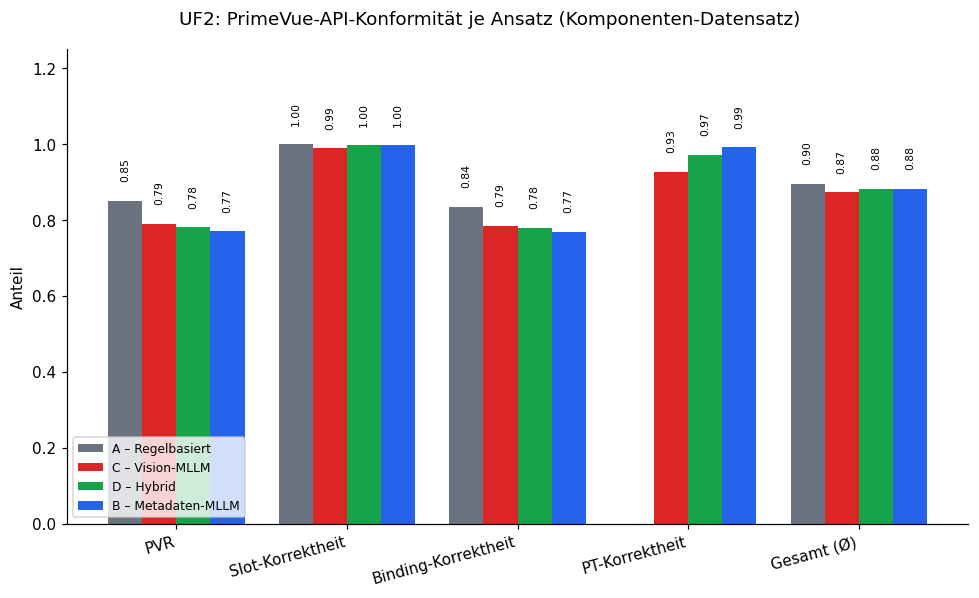

In [917]:
stage3_metrics = [
    ('prop_validity_rate', 'PVR'),
    ('slot_correctness', 'Slot-Korrektheit'),
    ('binding_correctness', 'Binding-Korrektheit'),
    ('pt_correctness', 'PT-Korrektheit'),
    ('api_conformance_avg', 'Gesamt (\u00d8)'),
]

s = uf2['components']['summary']
fig, ax = plt.subplots(figsize=(9, 5.5))
if s is not None:
    ov = code_quality_overview(s)
    plot_metric_group_bar(ax, ov, stage3_metrics, value_rotation=90, value_fontsize=7, offset=0.05)
ax.set_ylabel('Anteil')
ax.set_ylim(0, 1.25)
ax.legend(loc='lower left', fontsize=8)
fig.suptitle('UF2: PrimeVue-API-Konformit\u00e4t je Ansatz (Komponenten-Datensatz)')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'uf2_primevue-api-konformitaet_je_ansatz_komponenten.png', dpi=150, bbox_inches='tight')
plt.show()

UI dataset, split into `pretty`/`messy`.

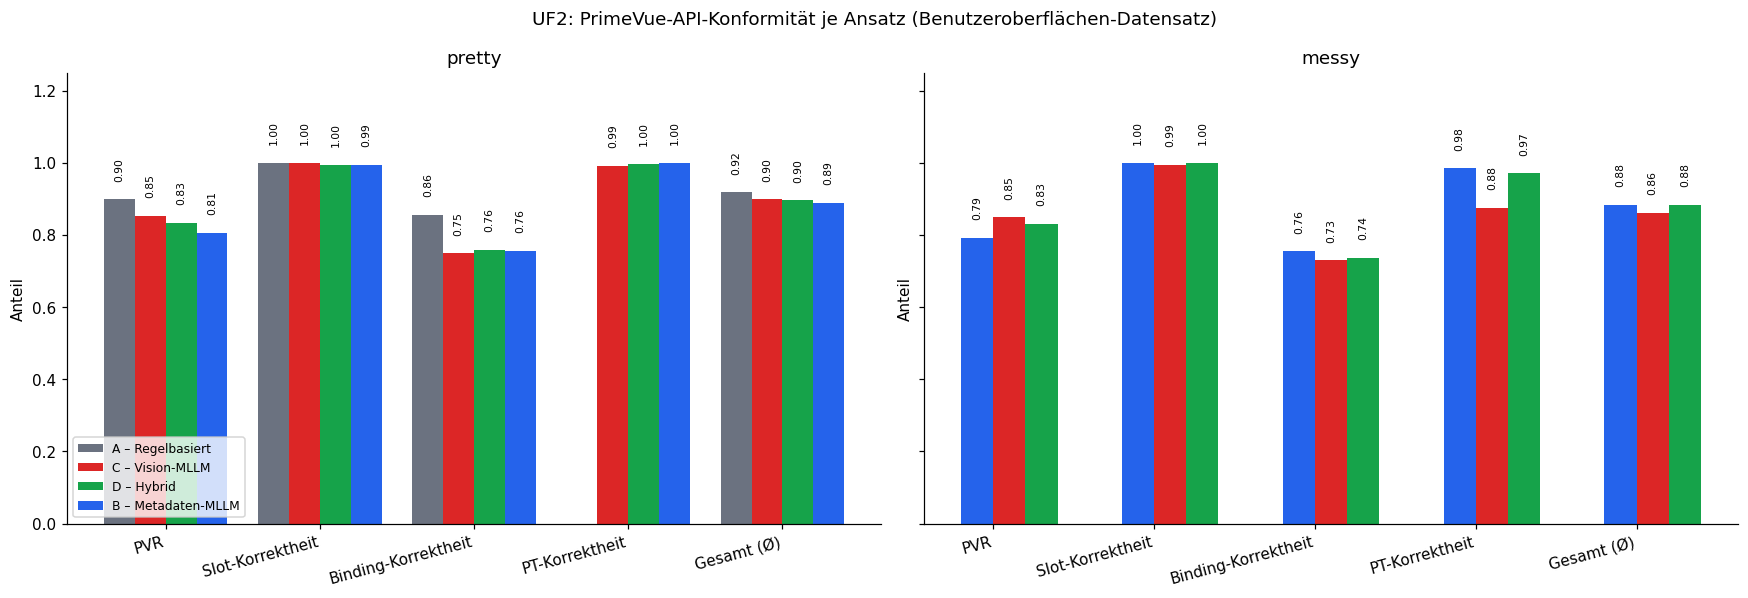

In [918]:
bg = uf2['uis']['by_group']
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), sharey=True)

for ax, variant in zip(axes, ['pretty', 'messy']):
    sub = variant_df(bg, variant)
    if sub is None or sub.empty:
        ax.set_visible(False)
        continue
    ov = code_quality_overview(sub)
    plot_metric_group_bar(ax, ov, stage3_metrics, value_rotation=90, value_fontsize=7, offset=0.05)
    ax.set_ylabel('Anteil')
    ax.set_ylim(0, 1.25)
    ax.set_title(variant)

axes[0].legend(loc='lower left', fontsize=8)
fig.suptitle('UF2: PrimeVue-API-Konformit\u00e4t je Ansatz (Benutzeroberfl\u00e4chen-Datensatz)')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'uf2_primevue-api-konformitaet_je_ansatz_benutzeroberflaechen.png', dpi=150, bbox_inches='tight')
plt.show()

#### Stage 4: Maintainability — AVU, CDR & Comment Density

Arbitrary Value Usage (bypassing the design system), Code Duplication Rate,
and Comment Density. All three are "share of ..." metrics, but note that for
Comment Density lower isn't automatically better (see `evaluation.md`) — it's
shown here for comparison across approaches, not as a target to minimize.
Components dataset first, then the UI dataset split into `pretty`/`messy`
panels.

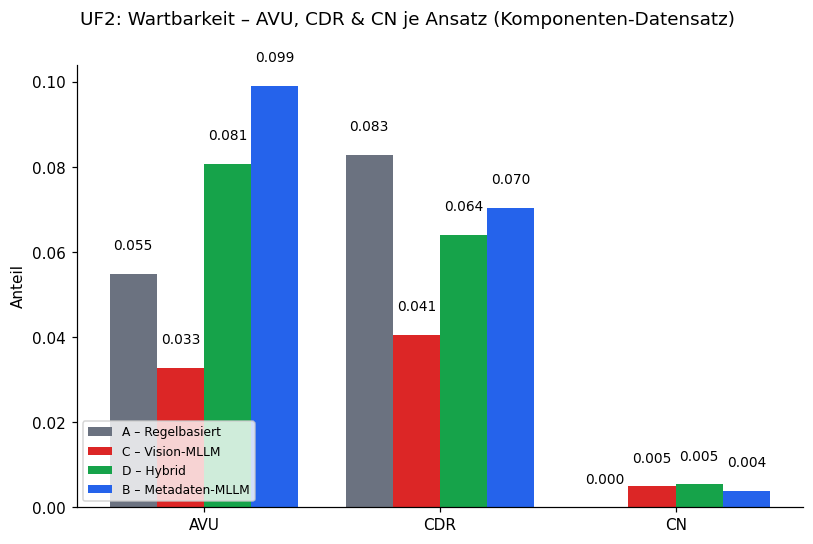

In [919]:
stage4a_metrics = [
    ('avu', 'AVU'),
    ('cdr', 'CDR'),
    ('cd', 'CN'),
]

s = uf2['components']['summary']
fig, ax = plt.subplots(figsize=(7.5, 5))
if s is not None:
    ov = code_quality_overview(s)
    plot_metric_group_bar(ax, ov, stage4a_metrics, label_rotation=0, fmt='{:.3f}', offset=0.005)
ax.set_ylabel('Anteil')
ax.legend(loc='lower left', fontsize=8)
fig.suptitle('UF2: Wartbarkeit \u2013 AVU, CDR & CN je Ansatz (Komponenten-Datensatz)')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'uf2_wartbarkeit_avu-cdr-cd_je_ansatz_komponenten.png', dpi=150, bbox_inches='tight')
plt.show()

UI dataset, split into `pretty`/`messy`.

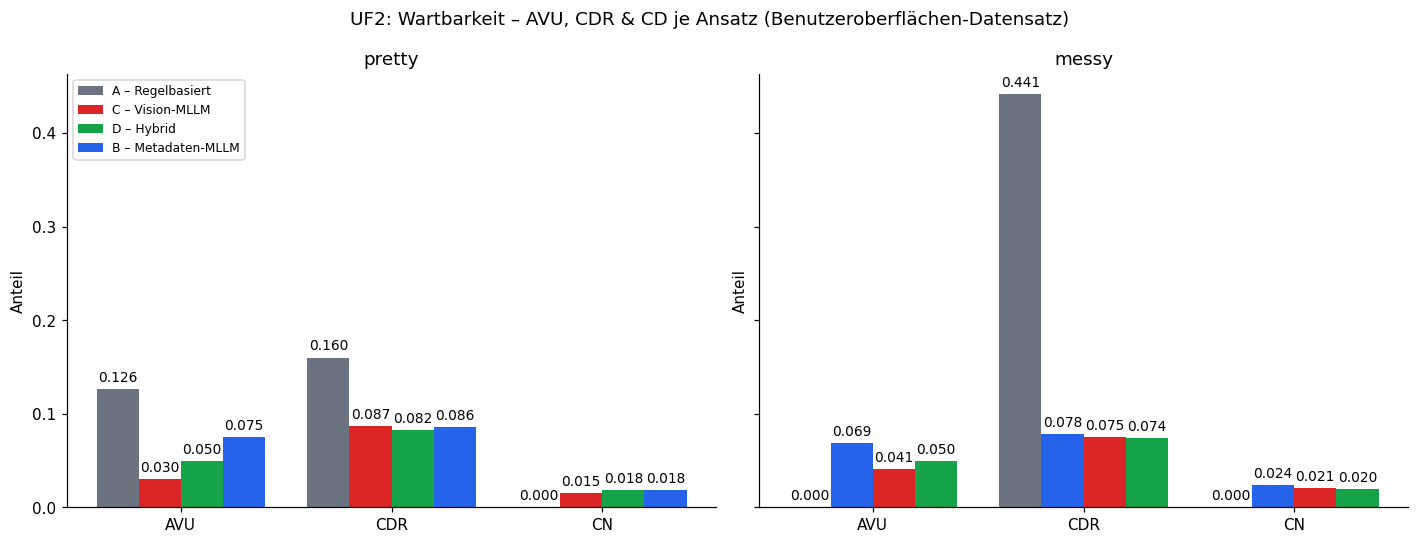

In [920]:
bg = uf2['uis']['by_group']
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, variant in zip(axes, ['pretty', 'messy']):
    sub = variant_df(bg, variant)
    if sub is None or sub.empty:
        ax.set_visible(False)
        continue
    ov = code_quality_overview(sub)
    plot_metric_group_bar(ax, ov, stage4a_metrics, label_rotation=0, fmt='{:.3f}', offset=0.005)
    ax.set_ylabel('Anteil')
    ax.set_title(variant)

axes[0].legend(loc='upper left', fontsize=8)
fig.suptitle('UF2: Wartbarkeit \u2013 AVU, CDR & CD je Ansatz (Benutzeroberfl\u00e4chen-Datensatz)')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'uf2_wartbarkeit_avu-cdr-cd_je_ansatz_benutzeroberflaechen.png', dpi=150, bbox_inches='tight')
plt.show()

#### Stage 4: Maintainability — Lines-of-Code ratio

`loc_ratio` = generated LOC / ground-truth LOC. The dashed line marks 1.0
(same length as the reference); bars well above it indicate bloat, bars well
below it indicate truncated/incomplete generation. Components dataset first,
then the UI dataset split into `pretty`/`messy`.

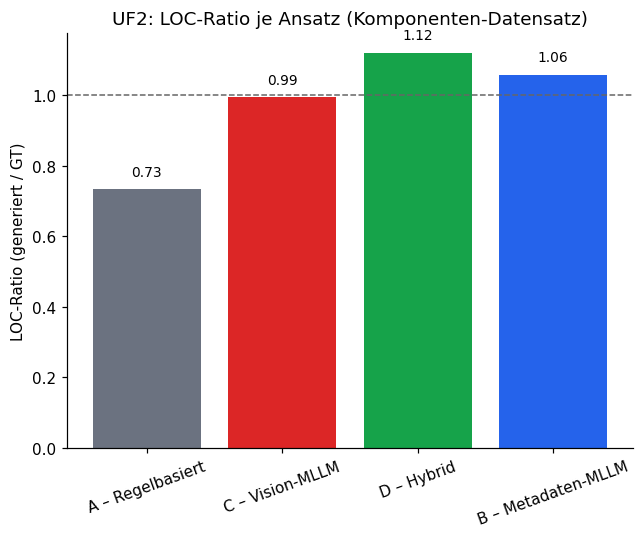

In [921]:
s = uf2['components']['summary']
fig, ax = plt.subplots(figsize=(6, 5))
if s is not None:
    ov = code_quality_overview(s)
    plot_single_metric_bar(ax, ov, 'loc_ratio')
ax.axhline(1.0, ls='--', color='#666', lw=1)
ax.set_ylabel('LOC-Ratio (generiert / GT)')
ax.set_title('UF2: LOC-Ratio je Ansatz (Komponenten-Datensatz)')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'uf2_loc-ratio_je_ansatz_komponenten.png', dpi=150, bbox_inches='tight')
plt.show()

UI dataset, split into `pretty`/`messy`.

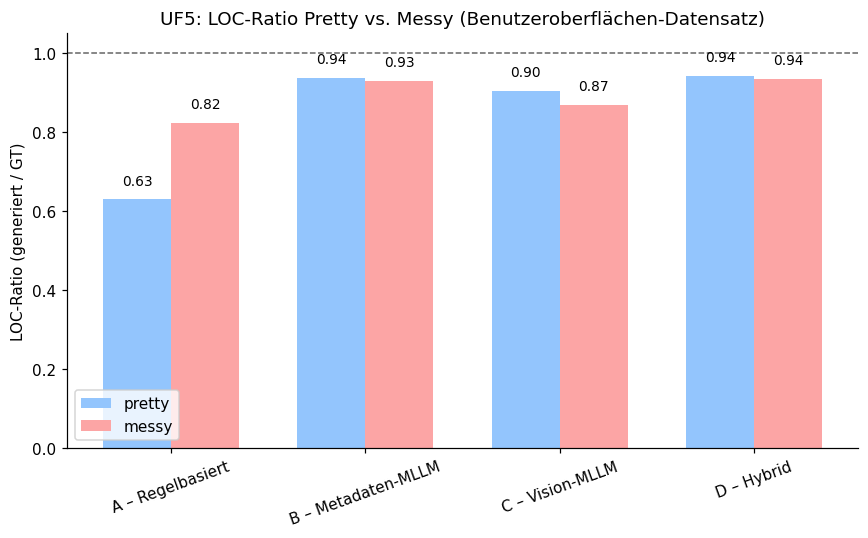

In [922]:
bg = uf2['uis']['by_group']
fig, ax = plt.subplots(figsize=(8, 5))
plot_pretty_messy_bar(ax, bg, 'loc_ratio_macro', legend_loc='lower left')
ax.axhline(1.0, ls='--', color='#666', lw=1)
ax.set_ylabel('LOC-Ratio (generiert / GT)')
ax.set_title('UF5: LOC-Ratio Pretty vs. Messy (Benutzeroberfl\u00e4chen-Datensatz)')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'uf5_loc-ratio_pretty_vs_messy.png', dpi=150, bbox_inches='tight')
plt.show()

#### Degradation / robustness — leading metrics (Parse-OK-Rate & PVR)

Of all Stage 0–4 metrics, `evaluation.md` tracks only two as leading
indicators for degradation/robustness: **Parse-OK-Rate** (Stage 0, structural
integrity) and **PVR** (Stage 3, API self-consistency). `degradation_factor
= metric_hard / metric_simple` (components) resp. `robustness =
metric_messy / metric_pretty` (UI).

In [923]:
deg2 = uf2['components'].get('degradation')
if deg2 is not None:
    print('--- Components dataset: degradation factor (Parse-OK-Rate & PVR) ---')
    deg_view = deg2.copy()
    deg_view['approach_label'] = deg_view['approach'].map(approach_label)
    display(deg_view.groupby('approach_label')[
        ['parse_ok_simple', 'parse_ok_medium', 'parse_ok_hard',
         'degradation_parse_ok_medium', 'degradation_parse_ok_hard',
         'pvr_simple', 'pvr_medium', 'pvr_hard',
         'degradation_pvr_medium', 'degradation_pvr_hard']
    ].mean().round(3).sort_values('degradation_pvr_hard', ascending=False))
else:
    print('Skipped: eval_code_quality_maintainability_components_degradation.csv not found.')

rob2 = uf2['uis'].get('robustness')
if rob2 is not None:
    print('\n--- UI dataset: robustness (Parse-OK-Rate & PVR) ---')
    rob_view = rob2.copy()
    rob_view['approach_label'] = rob_view['approach'].map(approach_label)
    display(rob_view.groupby('approach_label')[
        ['parse_ok_pretty', 'parse_ok_messy', 'robustness_parse_ok',
         'pvr_pretty', 'pvr_messy', 'robustness_pvr']
    ].mean().round(3).sort_values('robustness_pvr', ascending=False))
else:
    print('Skipped: eval_code_quality_maintainability_uis_robustness.csv not found.')

--- Components dataset: degradation factor (Parse-OK-Rate & PVR) ---


,parse_ok_simple,parse_ok_medium,parse_ok_hard,degradation_parse_ok_medium,degradation_parse_ok_hard,pvr_simple,pvr_medium,pvr_hard,degradation_pvr_medium,degradation_pvr_hard
approach_label,,,,,,,,,,
C - Vision MLLM,1.0,1.000,1.0,1.000,1.0,0.834,0.693,0.824,0.838,0.995
D - Hybrid,1.0,1.000,1.0,1.000,1.0,0.827,0.708,0.808,0.859,0.982
A - Rule-based,1.0,1.000,1.0,1.000,1.0,0.931,0.723,0.896,0.777,0.963
B - Metadata MLLM,1.0,0.994,1.0,0.994,1.0,0.832,0.700,0.785,0.843,0.946



--- UI dataset: robustness (Parse-OK-Rate & PVR) ---


,parse_ok_pretty,parse_ok_messy,robustness_parse_ok,pvr_pretty,pvr_messy,robustness_pvr
approach_label,,,,,,
C - Vision MLLM,1.000,1.0,1.000,0.853,0.849,0.997
D - Hybrid,1.000,1.0,1.000,0.834,0.830,0.997
B - Metadata MLLM,0.989,1.0,1.014,0.805,0.792,0.987
A - Rule-based,1.000,1.0,1.000,0.899,NaN,NaN


## UF3: Visual Fidelity

> *"To what extent do the [...] approaches achieve visual agreement with the
> Figma template [...]?"*

Data source: `eval_visual_fidelity_{TYPE}_summary.csv`,
`eval_visual_fidelity_{TYPE}_by_complexity.csv`, and
`eval_visual_fidelity_{TYPE}_degradation.csv` (components) /
`eval_visual_fidelity_{TYPE}_robustness.csv` (uis) from
`evaluation_visual_fidelity.ipynb`.

**Metrics:** Element-Match-Rate (EMR, F1-like over a Hungarian-matched set of
DOM elements between generated and ground-truth Storybook snapshots) plus,
averaged only over matched pairs: Mean IoU, Mean Position Similarity, Mean
Size Similarity, Mean Style-Match-Rate (13 checked CSS properties), and Mean
Text-Similarity.

**Limitations (see `evaluation.md`):** no pixel/screenshot comparison --
purely DOM structure, bounding boxes, and `getComputedStyle()`; matching is
text-*subordinate* (EMR reflects presence/type/rough position, not label
correctness -- always read together with Mean-Text-Similarity); style
matching covers only 13 predefined CSS properties, not a full CSSOM diff.

In [924]:
def load_uf3(type_: str) -> dict:
    d = EVAL_ROOT / type_
    data = {
        'summary':  load_csv(d / f'eval_visual_fidelity_{type_}_summary.csv'),
        'by_group': load_csv(d / f'eval_visual_fidelity_{type_}_by_complexity.csv'),
    }
    if type_ == 'components':
        data['degradation'] = load_csv(d / f'eval_visual_fidelity_{type_}_degradation.csv')
    else:
        data['robustness'] = load_csv(d / f'eval_visual_fidelity_{type_}_robustness.csv')
    return data


print('Loading UF3 data (Visual Fidelity)...')
uf3 = {t: load_uf3(t) for t in TYPES}

Loading UF3 data (Visual Fidelity)...
  [loaded] evaluations\components\eval_visual_fidelity_components_summary.csv  (55 rows)
  [loaded] evaluations\components\eval_visual_fidelity_components_by_complexity.csv  (165 rows)
  [loaded] evaluations\components\eval_visual_fidelity_components_degradation.csv  (55 rows)
  [loaded] evaluations\uis\eval_visual_fidelity_uis_summary.csv  (55 rows)
  [loaded] evaluations\uis\eval_visual_fidelity_uis_by_complexity.csv  (110 rows)
  [loaded] evaluations\uis\eval_visual_fidelity_uis_robustness.csv  (55 rows)


### Overview tables per approach

Mean (± standard deviation for EMR-macro, the leading metric) across all
strategies, models, and prompt strategies. Components dataset, then the UI
dataset split into `pretty`/`messy`.

In [925]:
def visual_fidelity_overview(df: pd.DataFrame) -> pd.DataFrame:
    g = df.groupby('approach', dropna=False).agg(
        emr_macro_mean=('element_match_rate_macro', 'mean'),
        emr_macro_std=('element_match_rate_macro', 'std'),
        emr_micro_mean=('element_match_rate_micro', 'mean'),
        mean_iou=('mean_iou_macro', 'mean'),
        mean_position_similarity=('mean_position_similarity_macro', 'mean'),
        mean_size_similarity=('mean_size_similarity_macro', 'mean'),
        mean_style_match_rate=('mean_style_match_rate_macro', 'mean'),
        mean_text_similarity=('mean_text_similarity_macro', 'mean'),
        n_configs=('element_match_rate_macro', 'size'),
    ).round(4).reset_index()
    g['approach_label'] = g['approach'].map(approach_label)
    cols = ['approach', 'approach_label', 'emr_macro_mean', 'emr_macro_std', 'emr_micro_mean',
            'mean_iou', 'mean_position_similarity', 'mean_size_similarity',
            'mean_style_match_rate', 'mean_text_similarity', 'n_configs']
    return g[cols].sort_values('approach').reset_index(drop=True)


uf3_overview_tables = {}
emr_cols = ['approach_label', 'emr_macro_mean', 'emr_macro_std', 'emr_micro_mean', 'n_configs']
submetric_cols = ['approach_label', 'mean_iou', 'mean_position_similarity', 'mean_size_similarity',
                   'mean_style_match_rate', 'mean_text_similarity']


def show_visual_fidelity_tables(df: pd.DataFrame, label: str, key: str):
    ov = visual_fidelity_overview(df)
    uf3_overview_tables[key] = ov
    print(f'\n--- {label}: Element-Match-Rate ---')
    display(ov[emr_cols])
    print(f'--- {label}: visual sub-metrics (matched pairs only) ---')
    display(ov[submetric_cols])


s = uf3['components']['summary']
if s is not None:
    show_visual_fidelity_tables(s, 'Components dataset', 'components')

for variant in ['pretty', 'messy']:
    sub = variant_df(uf3['uis']['by_group'], variant)
    if sub is None or sub.empty:
        continue
    show_visual_fidelity_tables(sub, f'UI dataset ({variant})', f'uis_{variant}')


--- Components dataset: Element-Match-Rate ---


,approach_label,emr_macro_mean,emr_macro_std,emr_micro_mean,n_configs
0,A - Rule-based,0.7804,NaN,0.6446,1
1,B - Metadata MLLM,0.8367,0.0518,0.8360,18
2,C - Vision MLLM,0.8618,0.0378,0.8435,18
3,D - Hybrid,0.8630,0.0427,0.8616,18


--- Components dataset: visual sub-metrics (matched pairs only) ---


,approach_label,mean_iou,mean_position_similarity,mean_size_similarity,mean_style_match_rate,mean_text_similarity
0,A - Rule-based,0.6028,0.9017,0.8253,0.9591,0.9948
1,B - Metadata MLLM,0.4555,0.8534,0.8380,0.9431,0.9936
2,C - Vision MLLM,0.5003,0.8783,0.8587,0.9478,0.9909
3,D - Hybrid,0.4949,0.8676,0.8677,0.9505,0.9939



--- UI dataset (pretty): Element-Match-Rate ---


...

,approach_label,mean_iou,mean_position_similarity,mean_size_similarity,mean_style_match_rate,mean_text_similarity
0,A - Rule-based,0.6145,0.9540,0.8173,0.9302,0.9859
1,B - Metadata MLLM,0.4852,0.8964,0.8400,0.9603,0.9923
2,C - Vision MLLM,0.5780,0.9364,0.8755,0.9505,0.9969
3,D - Hybrid,0.5602,0.9319,0.8938,0.9636,0.9974



--- UI dataset (messy): Element-Match-Rate ---


,approach_label,emr_macro_mean,emr_macro_std,emr_micro_mean,n_configs
0,A - Rule-based,0.6970,NaN,0.6692,1
1,B - Metadata MLLM,0.8446,0.1049,0.8986,18
2,C - Vision MLLM,0.9032,0.1116,0.9166,18
3,D - Hybrid,0.9125,0.0956,0.9318,18


--- UI dataset (messy): visual sub-metrics (matched pairs only) ---


,approach_label,mean_iou,mean_position_similarity,mean_size_similarity,mean_style_match_rate,mean_text_similarity
0,A - Rule-based,0.4144,0.8885,0.6746,0.8962,0.9721
1,B - Metadata MLLM,0.4948,0.9279,0.8042,0.9282,0.9878
2,C - Vision MLLM,0.5644,0.9407,0.8525,0.9383,0.9971
3,D - Hybrid,0.5783,0.9511,0.8644,0.9422,0.9969


#### Element-Match-Rate per approach — components dataset

Error bars show the standard deviation across all strategies/models/prompt
strategies. The UI-dataset equivalent, split into `pretty`/`messy`, is the
"Pretty vs. Messy" chart further below.

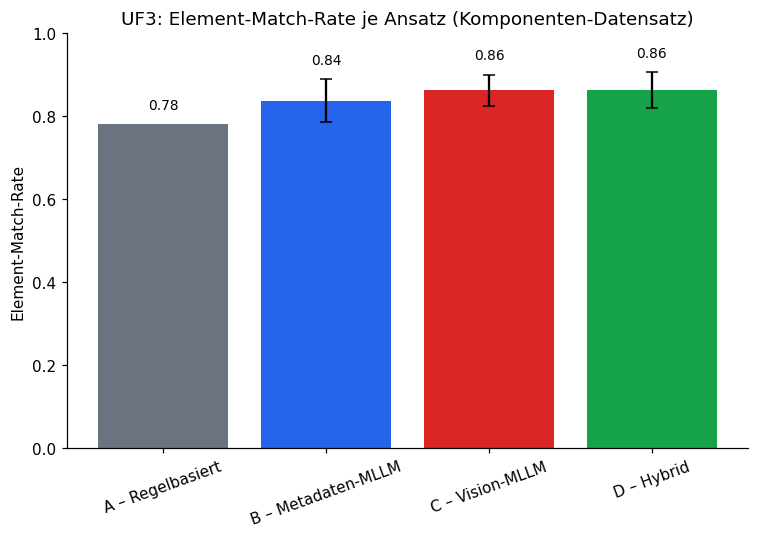

In [926]:
s = uf3['components']['summary']
fig, ax = plt.subplots(figsize=(7, 5))
if s is not None:
    ov = visual_fidelity_overview(s)
    plot_single_metric_bar(ax, ov, 'emr_macro_mean', error_col='emr_macro_std')
ax.set_ylabel('Element-Match-Rate')
ax.set_ylim(0, 1)
ax.set_title('UF3: Element-Match-Rate je Ansatz (Komponenten-Datensatz)')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'uf3_element-match-rate_je_ansatz_komponenten.png', dpi=150, bbox_inches='tight')
plt.show()

#### Element-Match-Rate per LLM model and approach

Only relevant for approaches B/C/D. Components dataset, then the UI dataset
split into `pretty`/`messy` panels.

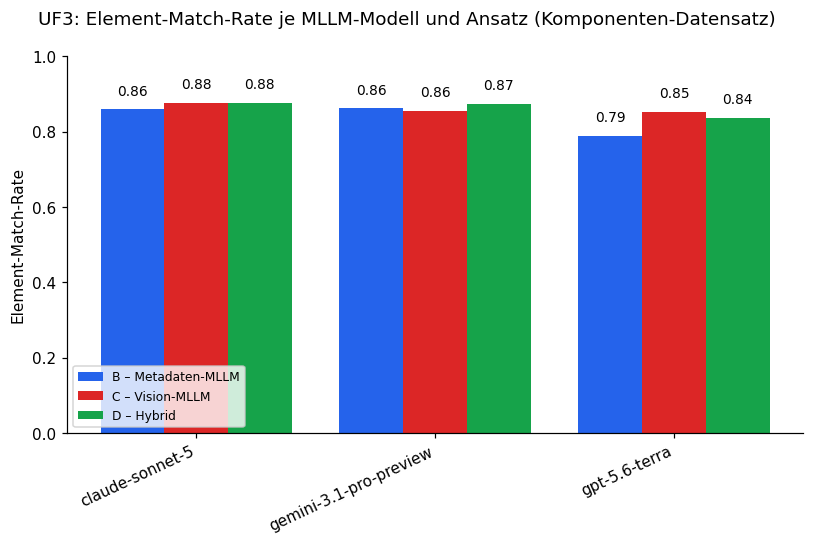

In [927]:
def model_breakdown_visual(df: pd.DataFrame) -> pd.DataFrame:
    llm = df[df['approach'] != 'a'].copy()
    return llm.groupby(['approach', 'model'], dropna=False)['element_match_rate_macro'].mean().reset_index()


s = uf3['components']['summary']
fig, ax = plt.subplots(figsize=(7.5, 5))
if s is not None:
    plot_model_breakdown(ax, model_breakdown_visual(s), 'element_match_rate_macro', 'Element-Match-Rate')
ax.legend(loc='lower left', fontsize=8)
fig.suptitle('UF3: Element-Match-Rate je MLLM-Modell und Ansatz (Komponenten-Datensatz)')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'uf3_element-match-rate_je_mllm-modell_und_ansatz_komponenten.png', dpi=150, bbox_inches='tight')
plt.show()

UI dataset, split into `pretty`/`messy`.

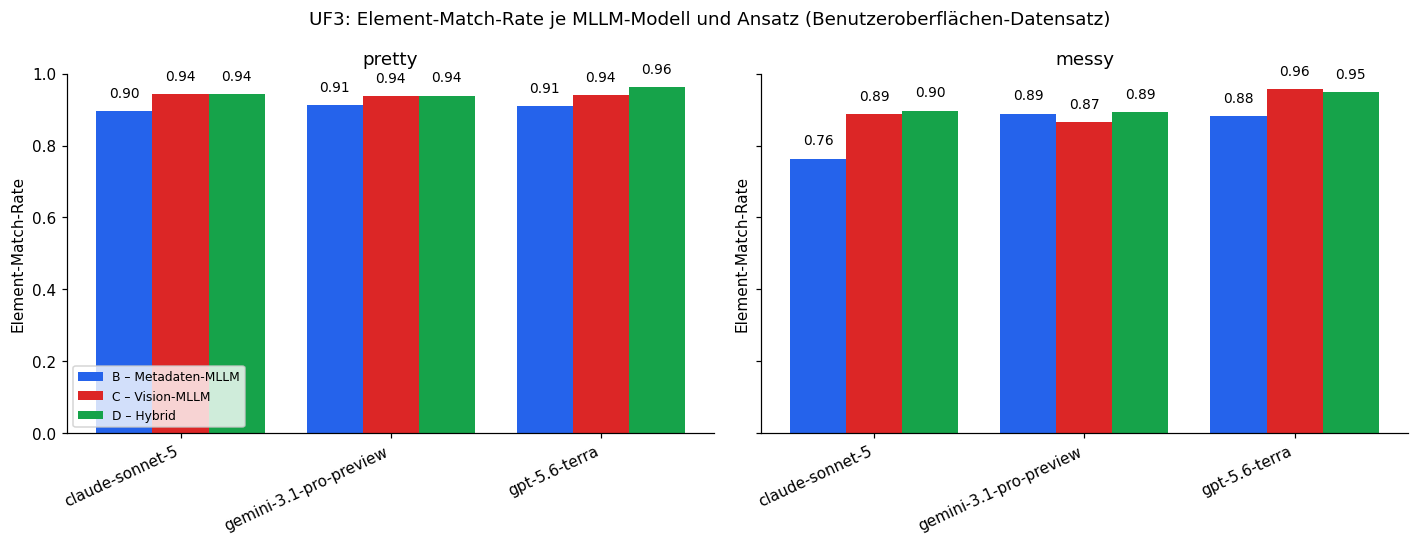

In [928]:
bg = uf3['uis']['by_group']
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, variant in zip(axes, ['pretty', 'messy']):
    sub = variant_df(bg, variant)
    if sub is None:
        ax.set_visible(False)
        continue
    plot_model_breakdown(ax, model_breakdown_visual(sub), 'element_match_rate_macro', 'Element-Match-Rate')
    ax.set_title(variant)

axes[0].legend(loc='lower left', fontsize=8)
fig.suptitle('UF3: Element-Match-Rate je MLLM-Modell und Ansatz (Benutzeroberfl\u00e4chen-Datensatz)')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'uf3_element-match-rate_je_mllm-modell_und_ansatz_benutzeroberflaechen.png', dpi=150, bbox_inches='tight')
plt.show()

#### Element-Match-Rate per context strategy and approach

Only relevant for approaches B/C/D. Same context-strategy numbering as in
UF1: **1** = no documentation, **2** = raw docs, **3** = cleaned/condensed
docs.

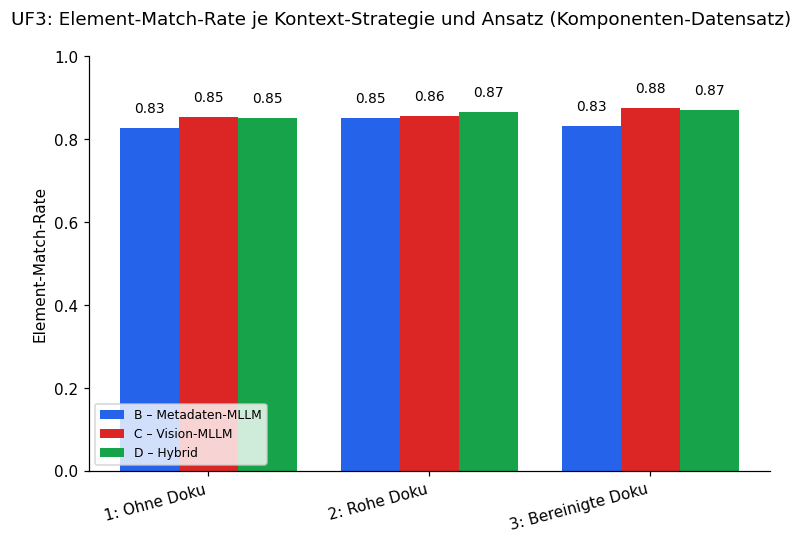

In [929]:
s = uf3['components']['summary']
fig, ax = plt.subplots(figsize=(7, 5))
if s is not None:
    plot_context_strategy_breakdown(ax, context_strategy_breakdown(s, 'element_match_rate_macro'),
                                     'element_match_rate_macro', 'Element-Match-Rate')
ax.legend(loc='lower left', fontsize=8)
fig.suptitle('UF3: Element-Match-Rate je Kontext-Strategie und Ansatz (Komponenten-Datensatz)')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'uf3_element-match-rate_je_kontext-strategie_und_ansatz_komponenten.png', dpi=150, bbox_inches='tight')
plt.show()

UI dataset, split into `pretty`/`messy`.

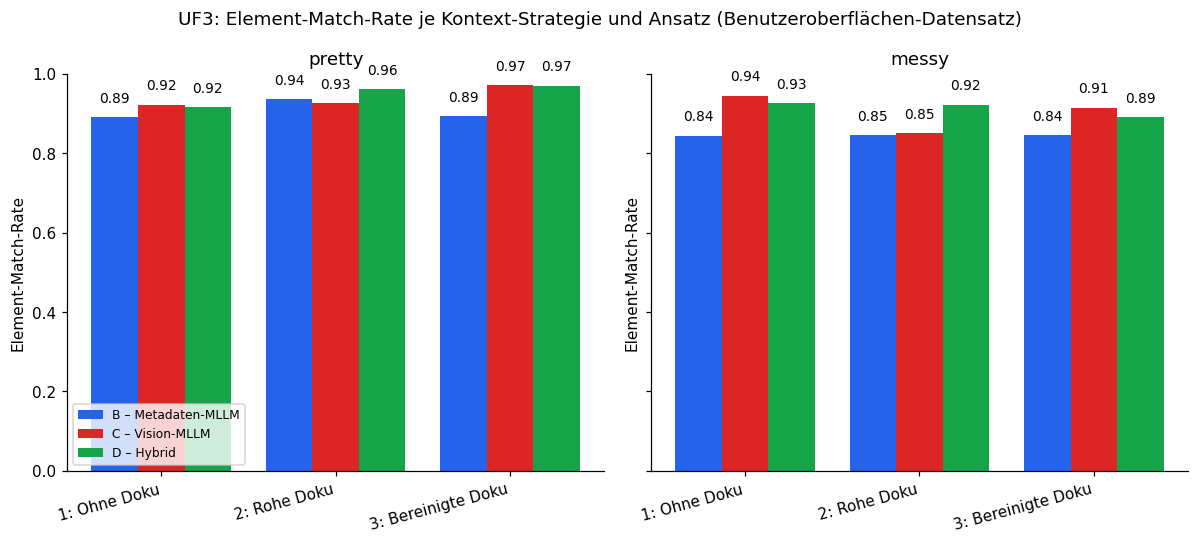

In [930]:
bg = uf3['uis']['by_group']
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)

for ax, variant in zip(axes, ['pretty', 'messy']):
    sub = variant_df(bg, variant)
    if sub is None:
        ax.set_visible(False)
        continue
    plot_context_strategy_breakdown(ax, context_strategy_breakdown(sub, 'element_match_rate_macro'),
                                     'element_match_rate_macro', 'Element-Match-Rate')
    ax.set_title(variant)

axes[0].legend(loc='lower left', fontsize=8)
fig.suptitle('UF3: Element-Match-Rate je Kontext-Strategie und Ansatz (Benutzeroberfl\u00e4chen-Datensatz)')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'uf3_element-match-rate_je_kontext-strategie_und_ansatz_benutzeroberflaechen.png', dpi=150, bbox_inches='tight')
plt.show()

#### Visual sub-metrics per approach

Mean IoU, Position/Size Similarity, Style-Match-Rate, and Text-Similarity,
averaged only over Hungarian-matched element pairs (see limitations above).
Components dataset first, then the UI dataset split into `pretty`/`messy`
panels.

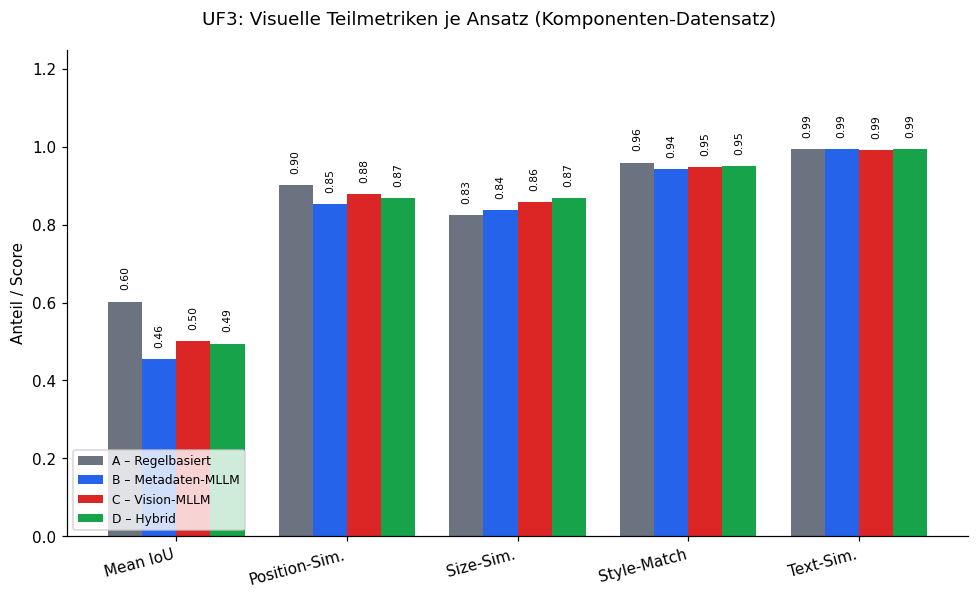

In [931]:
visual_submetrics = [
    ('mean_iou', 'Mean IoU'),
    ('mean_position_similarity', 'Position-Sim.'),
    ('mean_size_similarity', 'Size-Sim.'),
    ('mean_style_match_rate', 'Style-Match'),
    ('mean_text_similarity', 'Text-Sim.'),
]

s = uf3['components']['summary']
fig, ax = plt.subplots(figsize=(9, 5.5))
if s is not None:
    ov = visual_fidelity_overview(s)
    plot_metric_group_bar(ax, ov, visual_submetrics, value_rotation=90, value_fontsize=7, offset=0.03)
ax.set_ylabel('Anteil / Score')
ax.set_ylim(0, 1.25)
ax.legend(loc='lower left', fontsize=8)
fig.suptitle('UF3: Visuelle Teilmetriken je Ansatz (Komponenten-Datensatz)')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'uf3_teilmetriken_je_ansatz_komponenten.png', dpi=150, bbox_inches='tight')
plt.show()

UI dataset, split into `pretty`/`messy`.

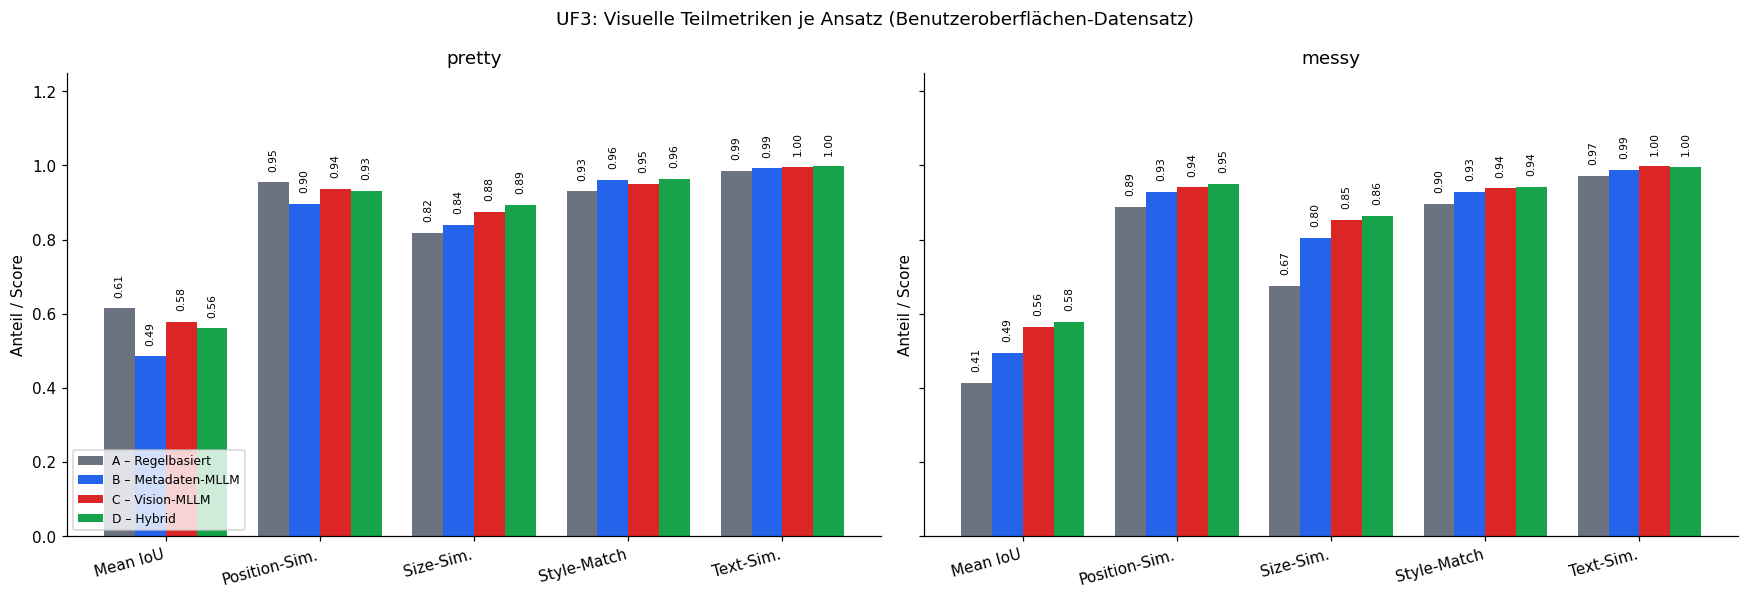

In [932]:
bg = uf3['uis']['by_group']
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), sharey=True)

for ax, variant in zip(axes, ['pretty', 'messy']):
    sub = variant_df(bg, variant)
    if sub is None or sub.empty:
        ax.set_visible(False)
        continue
    ov = visual_fidelity_overview(sub)
    plot_metric_group_bar(ax, ov, visual_submetrics, value_rotation=90, value_fontsize=7, offset=0.03)
    ax.set_ylabel('Anteil / Score')
    ax.set_ylim(0, 1.25)
    ax.set_title(variant)

axes[0].legend(loc='lower left', fontsize=8)
fig.suptitle('UF3: Visuelle Teilmetriken je Ansatz (Benutzeroberfl\u00e4chen-Datensatz)')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'uf3_teilmetriken_je_ansatz_benutzeroberflaechen.png', dpi=150, bbox_inches='tight')
plt.show()

#### Element-Match-Rate by complexity level (components dataset)

*(Chart text in German; the level names `simple`/`medium`/`hard` are
technical dataset labels and stay untranslated, matching `evaluation.md`.)*

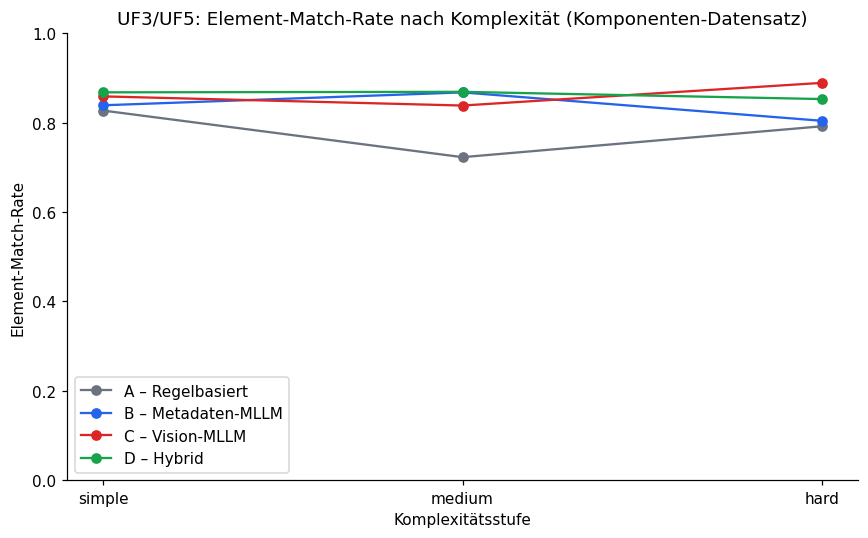

In [933]:
bg = uf3['components']['by_group']
if bg is not None:
    order = ['simple', 'medium', 'hard']
    fig, ax = plt.subplots(figsize=(8, 5))
    for a, sub in bg.groupby('approach'):
        agg = sub.groupby('complexity')['element_match_rate_macro'].mean().reindex(order)
        ax.plot(order, agg.values, marker='o', label=approach_label_de(a),
                color=APPROACH_COLORS.get(a, '#999'))
    ax.set_ylim(0, 1)
    ax.set_ylabel('Element-Match-Rate')
    ax.set_xlabel('Komplexit\u00e4tsstufe')
    ax.set_title('UF3/UF5: Element-Match-Rate nach Komplexit\u00e4t (Komponenten-Datensatz)')
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / 'uf5_element-match-rate_nach_komplexitaet.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Skipped: eval_visual_fidelity_components_by_complexity.csv not found.')

#### Element-Match-Rate: Pretty vs. Messy (UI dataset)

*(Chart text in German; `pretty`/`messy` are technical dataset labels and
stay untranslated, matching `evaluation.md`.)*

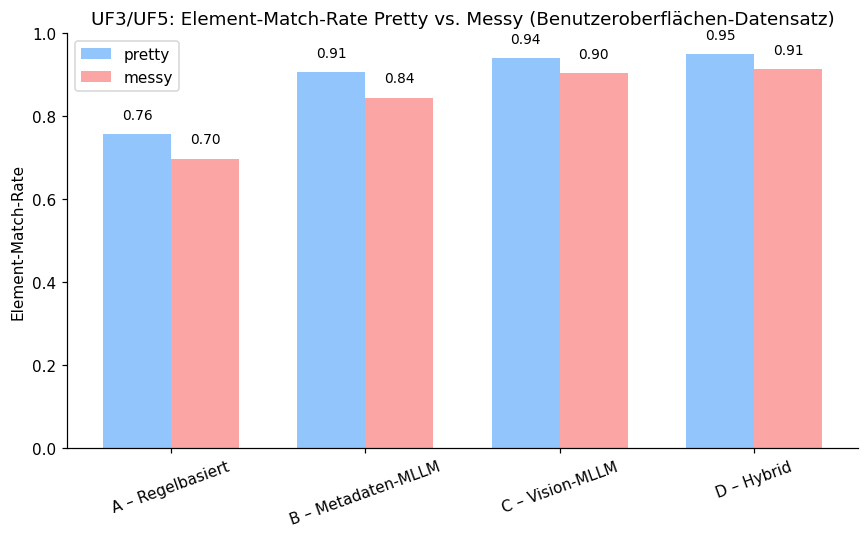

In [934]:
bg_uis = uf3['uis']['by_group']
fig, ax = plt.subplots(figsize=(8, 5))
plot_pretty_messy_bar(ax, bg_uis, 'element_match_rate_macro')
ax.set_ylabel('Element-Match-Rate')
ax.set_ylim(0, 1)
ax.set_title('UF3/UF5: Element-Match-Rate Pretty vs. Messy (Benutzeroberfl\u00e4chen-Datensatz)')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'uf5_element-match-rate_pretty_vs_messy.png', dpi=150, bbox_inches='tight')
plt.show()

#### Degradation / robustness factor per approach

`degradation_factor_hard = EMR_hard / EMR_simple` (components) resp.
`robustness_index = EMR_messy / EMR_pretty` (UI). (These are plain tables,
not charts, so they stay in English.)

In [935]:
deg3 = uf3['components'].get('degradation')
if deg3 is not None:
    print('--- Components dataset: degradation factor (EMR) ---')
    deg_view = deg3.copy()
    deg_view['approach_label'] = deg_view['approach'].map(approach_label)
    display(deg_view.groupby('approach_label')[
        ['emr_simple', 'emr_medium', 'emr_hard', 'degradation_emr_medium', 'degradation_emr_hard']
    ].mean().round(3).sort_index())
else:
    print('Skipped: eval_visual_fidelity_components_degradation.csv not found.')

rob3 = uf3['uis'].get('robustness')
if rob3 is not None:
    print('\n--- UI dataset: robustness (EMR) ---')
    rob_view = rob3.copy()
    rob_view['approach_label'] = rob_view['approach'].map(approach_label)
    display(rob_view.groupby('approach_label')[
        ['emr_pretty', 'emr_messy', 'robustness_index']
    ].mean().round(3).sort_index())
else:
    print('Skipped: eval_visual_fidelity_uis_robustness.csv not found.')

--- Components dataset: degradation factor (EMR) ---


,emr_simple,emr_medium,emr_hard,degradation_emr_medium,degradation_emr_hard
approach_label,,,,,
A - Rule-based,0.827,0.723,0.792,0.874,0.957
B - Metadata MLLM,0.839,0.867,0.804,1.037,0.958
C - Vision MLLM,0.859,0.838,0.889,0.980,1.038
D - Hybrid,0.868,0.869,0.853,1.003,0.981



--- UI dataset: robustness (EMR) ---


,emr_pretty,emr_messy,robustness_index
approach_label,,,
A - Rule-based,0.756,0.697,0.922
B - Metadata MLLM,0.906,0.845,0.936
C - Vision MLLM,0.940,0.903,0.966
D - Hybrid,0.949,0.913,0.962


## UF4: Rework Effort

> *"What degree of manual rework is required after each transformation
> method [...]?"*

Manual, three-tier assessment (trivial/moderate/fundamental) per review, no
automated export exists.

## UF5: Robustness

> *"How robust are the [...] approaches against varying structural quality
> of the Figma input data?"*

Uses the same metrics as UF1–UF3, evaluated on the `uis` dataset (`pretty` vs.
`messy`). Already covered above for UF1/F1 (section 1.1, pretty-vs-messy chart
& robustness-index table).

## UF6: Efficiency

> *"How do the [...] approaches differ in terms of processing time, token
> consumption, and monetary cost, and how do these efforts relate to the
> achieved result quality?"*

**Different data source than UF1–UF3.** There is no dedicated
`evaluation_efficiency.ipynb` -- the pipeline reports written directly by the
four `method-{a,b,c,d}-implementation.ipynb` notebooks during code generation
already contain everything needed (`results_{approach}_{type}[_{variant}]
[_{prompt_strategy}].csv` under `results/`). These are raw per-generation-call
logs, not pre-aggregated evaluation exports, so this section does its own
grouping/aggregation instead of just reading summary CSVs.

**Metrics:** processing time (`duration`, in ms) for all four approaches;
input/output tokens and cost (`cost_usd`) only for B, C, and D, since A is
rule-based and doesn't call an LLM.

In [936]:
RESULTS_DIR = Path('results')


def load_pipeline_reports() -> pd.DataFrame | None:
    """Loads and concatenates every pipeline report CSV written by the
    method-*-implementation notebooks during generation. Filename pattern:
      - Approach A:      results_a_{type}[_{variant}].csv
      - Approaches B/C/D: results_{approach}_{type}_{variant_}{prompt_strategy}.csv
    (variant is 'pretty'/'messy' for type='uis', absent for 'components';
    prompt_strategy is 'zero_shot'/'few_shot'). Missing files are skipped, as
    everywhere else in this notebook."""
    frames = []

    for type_ in TYPES:
        variants = [''] if type_ == 'components' else ['pretty', 'messy']
        for variant in variants:
            suffix = f'_{variant}' if variant else ''
            df = load_csv(RESULTS_DIR / f'results_a_{type_}{suffix}.csv')
            if df is not None:
                frames.append(df)

        for approach in ['b', 'c', 'd']:
            for variant in variants:
                vprefix = f'{variant}_' if variant else ''
                for prompt_strategy in ['zero_shot', 'few_shot']:
                    df = load_csv(RESULTS_DIR / f'results_{approach}_{type_}_{vprefix}{prompt_strategy}.csv')
                    if df is not None:
                        frames.append(df)

    if not frames:
        return None

    combined = pd.concat(frames, ignore_index=True)
    combined['approach'] = combined['strategy'].str[0]
    combined['duration_s'] = combined['duration'] / 1000
    return combined


print('Loading UF6 data (pipeline reports)...')
uf6_all = load_pipeline_reports()

if uf6_all is not None:
    print(f'  Combined: {len(uf6_all)} rows, approaches: {sorted(uf6_all["approach"].unique())}')
    uf6_components = uf6_all[uf6_all['type'] == 'components'].copy()
    uf6_uis = uf6_all[uf6_all['type'] == 'uis'].copy()
else:
    uf6_components = uf6_uis = None

Loading UF6 data (pipeline reports)...
  [loaded] results\results_a_components.csv  (30 rows)
  [loaded] results\results_b_components_zero_shot.csv  (270 rows)
  [loaded] results\results_b_components_few_shot.csv  (270 rows)
  [loaded] results\results_c_components_zero_shot.csv  (270 rows)
  [loaded] results\results_c_components_few_shot.csv  (270 rows)
  [loaded] results\results_d_components_zero_shot.csv  (270 rows)
  [loaded] results\results_d_components_few_shot.csv  (270 rows)
  [loaded] results\results_a_uis_pretty.csv  (5 rows)
  [loaded] results\results_a_uis_messy.csv  (5 rows)
  [loaded] results\results_b_uis_pretty_zero_shot.csv  (45 rows)
  [loaded] results\results_b_uis_pretty_few_shot.csv  (45 rows)
  [loaded] results\results_b_uis_messy_zero_shot.csv  (45 rows)
  [loaded] results\results_b_uis_messy_few_shot.csv  (45 rows)
  [loaded] results\results_c_uis_pretty_zero_shot.csv  (45 rows)
  [loaded] results\results_c_uis_pretty_few_shot.csv  (45 rows)
  [loaded] results\re

### Overview tables per approach

`duration` is in milliseconds. Token/cost columns are `NaN` (not `0`) for
approach A -- it never calls an LLM, so "no cost" would be misleading
shorthand for "not applicable". Components dataset, then UI dataset split
into `pretty`/`messy`.

In [937]:
def efficiency_overview(df: pd.DataFrame) -> pd.DataFrame:
    g = df.groupby('approach', dropna=False).agg(
        duration_ms_mean=('duration', 'mean'),
        duration_ms_median=('duration', 'median'),
        input_tokens_mean=('input_tokens', 'mean'),
        output_tokens_mean=('output_tokens', 'mean'),
        cost_usd_mean=('cost_usd', 'mean'),
        cost_usd_sum=('cost_usd', 'sum'),
        n=('duration', 'size'),
    ).round(4).reset_index()
    # sum() of an all-NaN column returns 0.0, not NaN -- would misleadingly
    # imply "$0 cost" for approach A instead of "not applicable".
    llm_cols = ['input_tokens_mean', 'output_tokens_mean', 'cost_usd_mean', 'cost_usd_sum']
    g.loc[g['approach'] == 'a', llm_cols] = np.nan
    g['approach_label'] = g['approach'].map(approach_label)
    return g.sort_values('approach').reset_index(drop=True)


uf6_overview_tables = {}

if uf6_components is not None:
    print('\n--- Components dataset ---')
    ov = efficiency_overview(uf6_components)
    uf6_overview_tables['components'] = ov
    display(ov.drop(columns='approach'))

for variant in ['pretty', 'messy']:
    if uf6_uis is None:
        break
    sub = uf6_uis[uf6_uis['variant'] == variant]
    if sub.empty:
        continue
    print(f'\n--- UI dataset ({variant}) ---')
    ov = efficiency_overview(sub)
    uf6_overview_tables[f'uis_{variant}'] = ov
    display(ov.drop(columns='approach'))


--- Components dataset ---


,duration_ms_mean,duration_ms_median,input_tokens_mean,output_tokens_mean,cost_usd_mean,cost_usd_sum,n,approach_label
0,0.3209,0.3172,NaN,NaN,NaN,NaN,30,A - Rule-based
1,13507.3430,10352.8458,24113.7185,1235.1519,0.0506,27.3466,540,B - Metadata MLLM
2,14436.5114,10687.7289,15159.5741,1353.5852,0.0398,21.4983,540,C - Vision MLLM
3,13626.3324,11180.7461,26287.8426,1339.9907,0.0601,32.4356,540,D - Hybrid



--- UI dataset (pretty) ---


,duration_ms_mean,duration_ms_median,input_tokens_mean,output_tokens_mean,cost_usd_mean,cost_usd_sum,n,approach_label
0,1.4391,1.1504,NaN,NaN,NaN,NaN,5,A - Rule-based
1,30684.8351,23728.1661,77194.4556,3215.5556,0.1813,16.3134,90,B - Metadata MLLM
2,30801.5726,24313.1701,31821.6222,2888.3000,0.0970,8.7307,90,C - Vision MLLM
3,30924.5868,24185.2266,80801.8111,3039.2778,0.1824,16.4130,90,D - Hybrid



--- UI dataset (messy) ---


,duration_ms_mean,duration_ms_median,input_tokens_mean,output_tokens_mean,cost_usd_mean,cost_usd_sum,n,approach_label
0,1.5450,1.4296,NaN,NaN,NaN,NaN,5,A - Rule-based
1,26416.9709,21654.4547,34580.0778,3026.8333,0.0913,8.2202,90,B - Metadata MLLM
2,26956.1281,24013.5888,4716.9000,3073.2333,0.0436,3.9225,90,C - Vision MLLM
3,29595.1988,22623.0211,37492.5444,2853.2556,0.0969,8.7219,90,D - Hybrid


#### Processing time per approach

Log scale on the y-axis, since approach A (a few hundred microseconds, pure
string/AST processing) and the LLM-based approaches (several seconds per
call) differ by 3-4 orders of magnitude. Exact mean/median values are in the
table above rather than as bar labels, which wouldn't be legible on a log
axis for values this far apart. Components dataset first, then the UI
dataset split into `pretty`/`messy`.

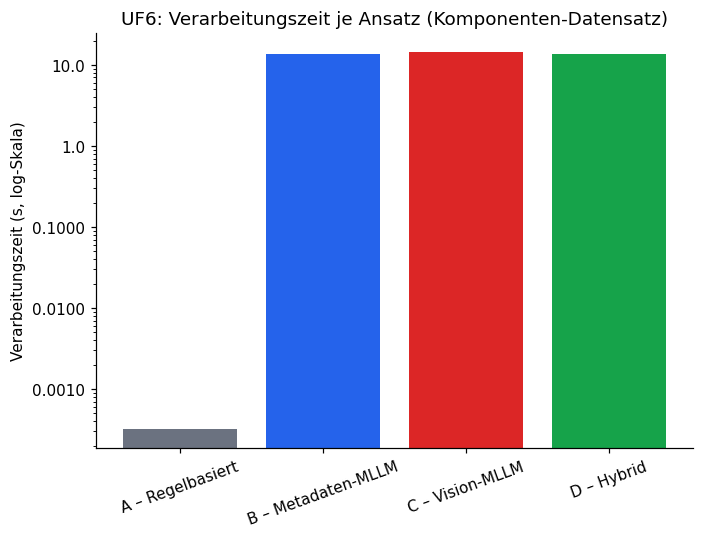

In [938]:
def format_seconds(y, _):
    if y < 1:
        return f'{y:.4f}'
    return f'{y:,.1f}'


s = uf6_components
fig, ax = plt.subplots(figsize=(6.5, 5))
if s is not None:
    ov = efficiency_overview(s)
    colors = [APPROACH_COLORS.get(a, '#999') for a in ov['approach']]
    labels_de = [approach_label_de(a) for a in ov['approach']]
    ax.bar(labels_de, ov['duration_ms_mean'] / 1000, color=colors)
ax.set_yscale('log')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(format_seconds))
ax.yaxis.set_minor_formatter(mticker.NullFormatter())
ax.set_ylabel('Verarbeitungszeit (s, log-Skala)')
ax.tick_params(axis='x', rotation=20)
ax.set_title('UF6: Verarbeitungszeit je Ansatz (Komponenten-Datensatz)')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'uf6_verarbeitungszeit_je_ansatz_komponenten.png', dpi=150, bbox_inches='tight')
plt.show()

UI dataset, split into `pretty`/`messy`.

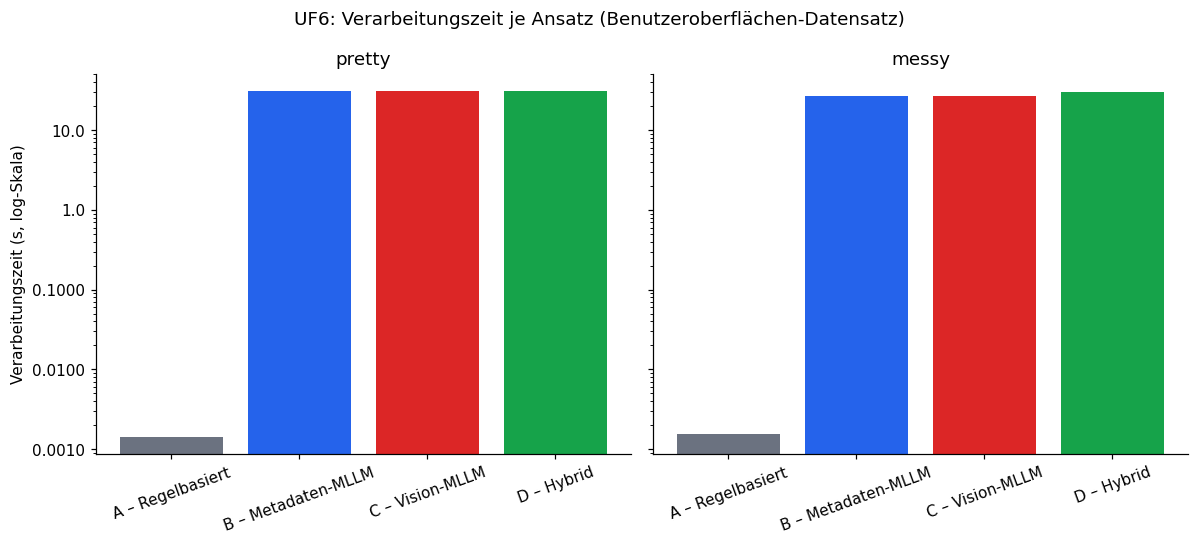

In [939]:
def format_seconds(y, _):
    if y < 1:
        return f'{y:.4f}'
    return f'{y:,.1f}'


fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)

for ax, variant in zip(axes, ['pretty', 'messy']):
    if uf6_uis is None:
        ax.set_visible(False)
        continue
    sub = uf6_uis[uf6_uis['variant'] == variant]
    if sub.empty:
        ax.set_visible(False)
        continue
    ov = efficiency_overview(sub)
    colors = [APPROACH_COLORS.get(a, '#999') for a in ov['approach']]
    labels_de = [approach_label_de(a) for a in ov['approach']]
    ax.bar(labels_de, ov['duration_ms_mean'] / 1000, color=colors)
    ax.set_yscale('log')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(format_seconds))
    ax.yaxis.set_minor_formatter(mticker.NullFormatter())
    ax.tick_params(axis='x', rotation=20)
    ax.set_title(variant)

axes[0].set_ylabel('Verarbeitungszeit (s, log-Skala)')
fig.suptitle('UF6: Verarbeitungszeit je Ansatz (Benutzeroberfl\u00e4chen-Datensatz)')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'uf6_verarbeitungszeit_je_ansatz_benutzeroberflaechen.png', dpi=150, bbox_inches='tight')
plt.show()

#### Token consumption per approach

Only approaches B/C/D (A doesn't call an LLM). Components dataset first, then
the UI dataset split into `pretty`/`messy`.

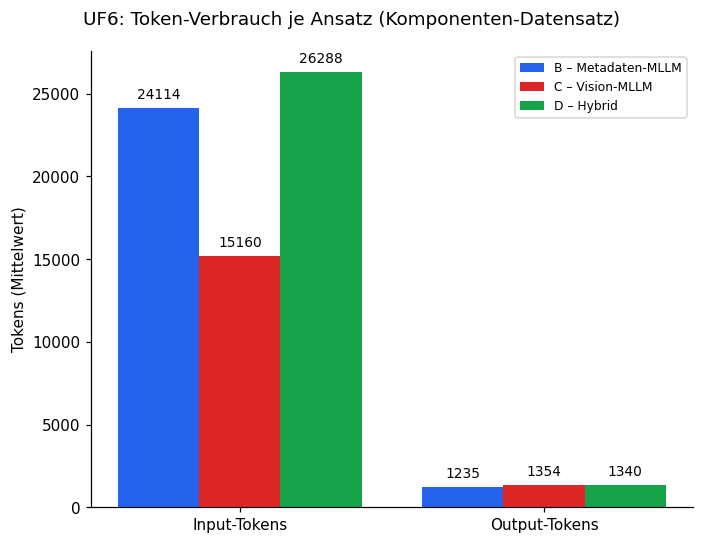

In [940]:
token_metrics = [
    ('input_tokens_mean', 'Input-Tokens'),
    ('output_tokens_mean', 'Output-Tokens'),
]

s = uf6_components
fig, ax = plt.subplots(figsize=(6.5, 5))
if s is not None:
    ov = efficiency_overview(s)
    ov_llm = ov[ov['approach'] != 'a']
    plot_metric_group_bar(ax, ov_llm, token_metrics, label_rotation=0, fmt='{:.0f}', offset=400)
ax.set_ylabel('Tokens (Mittelwert)')
ax.legend(loc='upper right', fontsize=8)
fig.suptitle('UF6: Token-Verbrauch je Ansatz (Komponenten-Datensatz)')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'uf6_token-verbrauch_je_ansatz_komponenten.png', dpi=150, bbox_inches='tight')
plt.show()

UI dataset, split into `pretty`/`messy`.

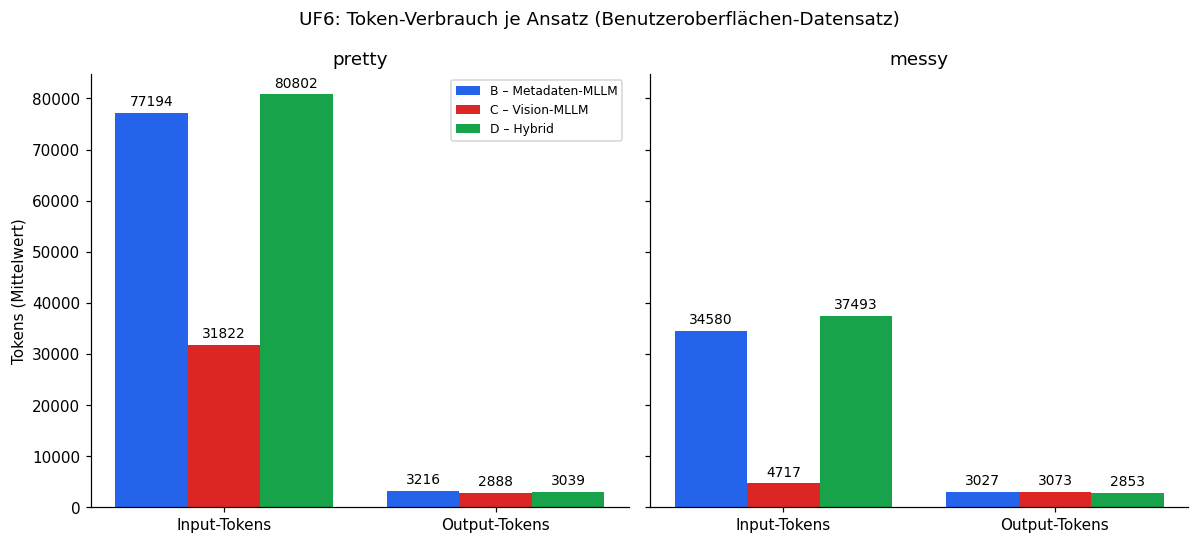

In [941]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)

for ax, variant in zip(axes, ['pretty', 'messy']):
    if uf6_uis is None:
        ax.set_visible(False)
        continue
    sub = uf6_uis[uf6_uis['variant'] == variant]
    if sub.empty:
        ax.set_visible(False)
        continue
    ov = efficiency_overview(sub)
    ov_llm = ov[ov['approach'] != 'a']
    plot_metric_group_bar(ax, ov_llm, token_metrics, label_rotation=0, fmt='{:.0f}', offset=800)
    ax.set_title(variant)

axes[0].set_ylabel('Tokens (Mittelwert)')
axes[0].legend(loc='upper right', fontsize=8)
fig.suptitle('UF6: Token-Verbrauch je Ansatz (Benutzeroberfl\u00e4chen-Datensatz)')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'uf6_token-verbrauch_je_ansatz_benutzeroberflaechen.png', dpi=150, bbox_inches='tight')
plt.show()

#### Cost per transformation, per approach

Mean cost in USD per single generation call. Only approaches B/C/D.
Components dataset first, then the UI dataset split into `pretty`/`messy`.

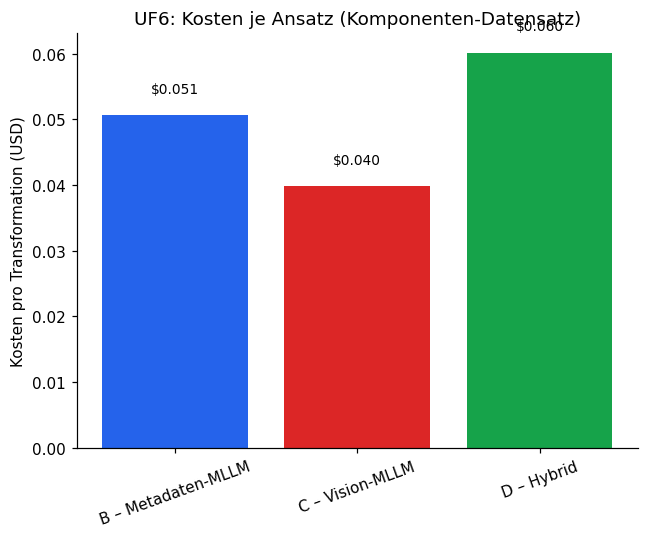

In [942]:
s = uf6_components
fig, ax = plt.subplots(figsize=(6, 5))
if s is not None:
    ov = efficiency_overview(s)
    ov_llm = ov[ov['approach'] != 'a']
    plot_single_metric_bar(ax, ov_llm, 'cost_usd_mean', fmt='${:.3f}', offset=0.003)
ax.set_ylabel('Kosten pro Transformation (USD)')
ax.set_title('UF6: Kosten je Ansatz (Komponenten-Datensatz)')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'uf6_kosten_je_ansatz_komponenten.png', dpi=150, bbox_inches='tight')
plt.show()

UI dataset, split into `pretty`/`messy`.

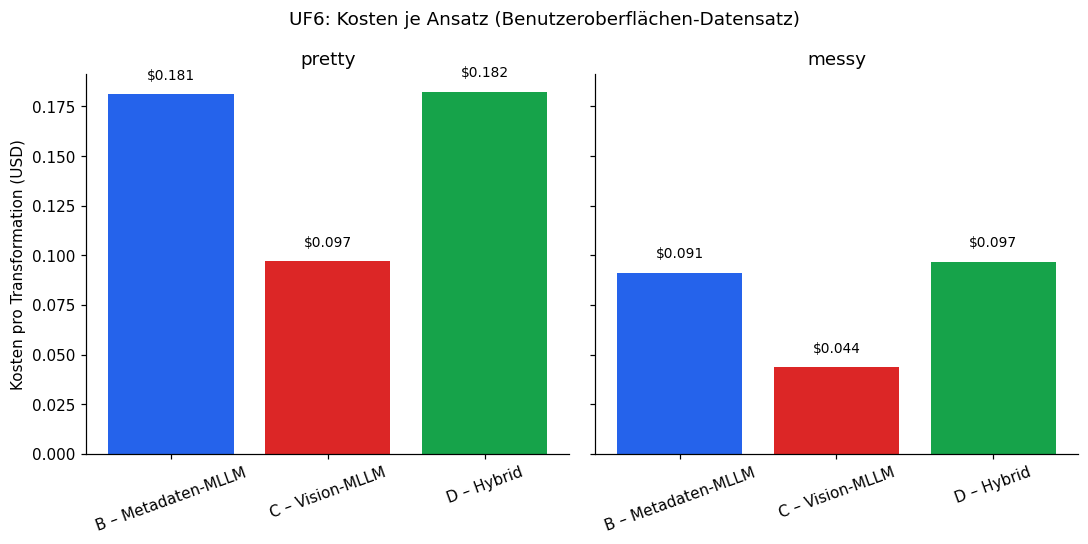

In [943]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

for ax, variant in zip(axes, ['pretty', 'messy']):
    if uf6_uis is None:
        ax.set_visible(False)
        continue
    sub = uf6_uis[uf6_uis['variant'] == variant]
    if sub.empty:
        ax.set_visible(False)
        continue
    ov = efficiency_overview(sub)
    ov_llm = ov[ov['approach'] != 'a']
    plot_single_metric_bar(ax, ov_llm, 'cost_usd_mean', fmt='${:.3f}', offset=0.006)
    ax.set_title(variant)

axes[0].set_ylabel('Kosten pro Transformation (USD)')
fig.suptitle('UF6: Kosten je Ansatz (Benutzeroberfl\u00e4chen-Datensatz)')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'uf6_kosten_je_ansatz_benutzeroberflaechen.png', dpi=150, bbox_inches='tight')
plt.show()

#### Cost per context strategy and approach

Same context-strategy numbering as in UF1/UF3: **1** = no documentation,
**2** = raw docs, **3** = cleaned/condensed docs. More documentation in the
context directly drives up input tokens, so this is expected to show a clear
cost gradient.

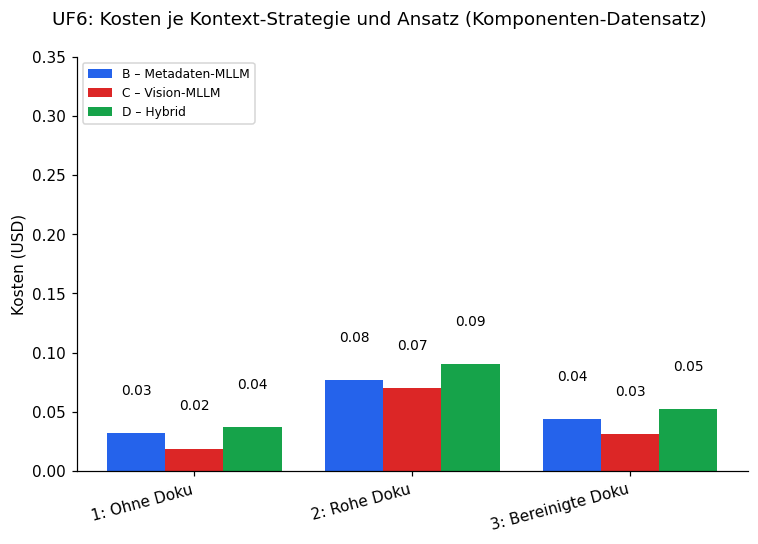

In [944]:
s = uf6_components
fig, ax = plt.subplots(figsize=(7, 5))
if s is not None:
    cb = context_strategy_breakdown(s, 'cost_usd')
    plot_context_strategy_breakdown(ax, cb, 'cost_usd', 'Kosten (USD)')
    ax.set_ylim(0, max(0.35, cb['cost_usd'].max() * 1.2 if not cb.empty else 0.35))
ax.legend(loc='upper left', fontsize=8)
fig.suptitle('UF6: Kosten je Kontext-Strategie und Ansatz (Komponenten-Datensatz)')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'uf6_kosten_je_kontext-strategie_und_ansatz_komponenten.png', dpi=150, bbox_inches='tight')
plt.show()

UI dataset, split into `pretty`/`messy`. *(Chart text in German.)*

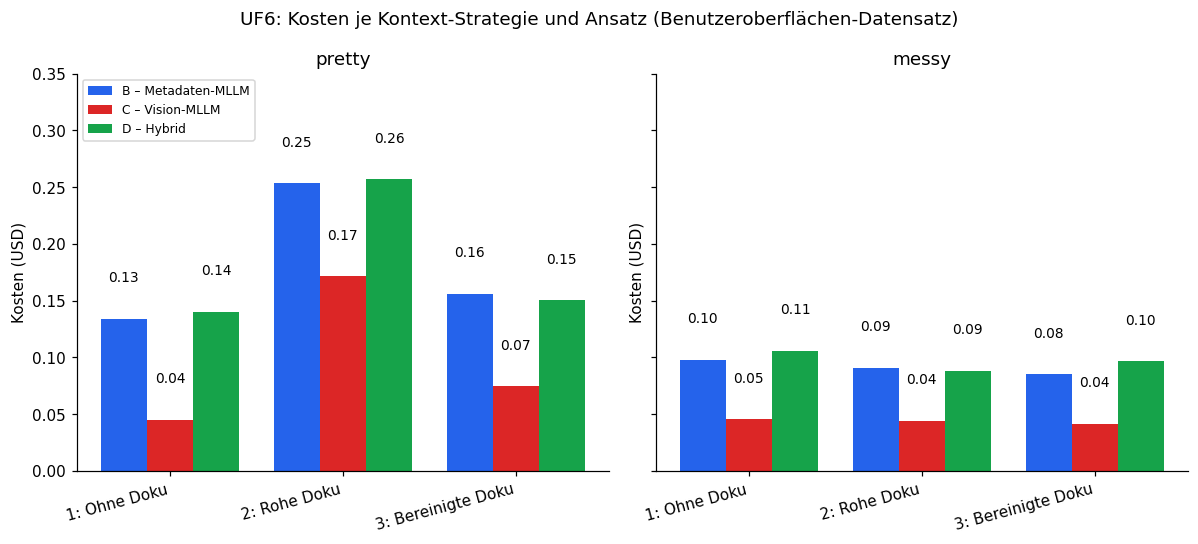

In [945]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)

for ax, variant in zip(axes, ['pretty', 'messy']):
    if uf6_uis is None:
        ax.set_visible(False)
        continue
    sub = uf6_uis[uf6_uis['variant'] == variant]
    if sub.empty:
        ax.set_visible(False)
        continue
    cb = context_strategy_breakdown(sub, 'cost_usd')
    plot_context_strategy_breakdown(ax, cb, 'cost_usd', 'Kosten (USD)')
    ax.set_ylim(0, 1)  # placeholder, corrected below once all panels are drawn
    ax.set_title(variant)

# shared y-limit across both panels, based on the actual data
max_cost = 0.35
if uf6_uis is not None:
    for variant in ['pretty', 'messy']:
        sub = uf6_uis[uf6_uis['variant'] == variant]
        if not sub.empty:
            cb = context_strategy_breakdown(sub, 'cost_usd')
            if not cb.empty:
                max_cost = max(max_cost, cb['cost_usd'].max() * 1.2)
for ax in axes:
    ax.set_ylim(0, max_cost)

axes[0].set_ylabel('Kosten (USD)')
axes[0].legend(loc='upper left', fontsize=8)
fig.suptitle('UF6: Kosten je Kontext-Strategie und Ansatz (Benutzeroberfl\u00e4chen-Datensatz)')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'uf6_kosten_je_kontext-strategie_und_ansatz_benutzeroberflaechen.png', dpi=150, bbox_inches='tight')
plt.show()

#### Total cost per approach and strategy

Sum (not mean) of `cost_usd` across all generation calls -- the actual
dollar amount spent per strategy over the whole evaluation run, as called for
in `evaluation.md` ("Summe der Kosten pro Strategie"). (Plain table, stays in
English.)

In [946]:
def total_cost_by_strategy(df: pd.DataFrame) -> pd.DataFrame:
    llm = df[df['approach'] != 'a']
    g = llm.groupby('strategy', dropna=False)['cost_usd'].agg(
        cost_usd_total='sum', cost_usd_mean='mean', n='size'
    ).round(4).reset_index()
    return g.sort_values('strategy').reset_index(drop=True)


if uf6_components is not None:
    print('--- Components dataset: total cost per strategy ---')
    display(total_cost_by_strategy(uf6_components))

for variant in ['pretty', 'messy']:
    if uf6_uis is None:
        break
    sub = uf6_uis[uf6_uis['variant'] == variant]
    if sub.empty:
        continue
    print(f'\n--- UI dataset ({variant}): total cost per strategy ---')
    display(total_cost_by_strategy(sub))

--- Components dataset: total cost per strategy ---


,strategy,cost_usd_total,cost_usd_mean,n
0,b1,5.7048,0.0317,180
1,b2,13.7489,0.0764,180
2,b3,7.8928,0.0438,180
3,c1,3.4052,0.0189,180
4,c2,12.5448,0.0697,180
5,c3,5.5482,0.0308,180
6,d1,6.6926,0.0372,180
7,d2,16.2831,0.0905,180
8,d3,9.4600,0.0526,180



--- UI dataset (pretty): total cost per strategy ---


,strategy,cost_usd_total,cost_usd_mean,n
0,b1,4.0247,0.1342,30
1,b2,7.6033,0.2534,30
2,b3,4.6854,0.1562,30
3,c1,1.3463,0.0449,30
4,c2,5.1431,0.1714,30
5,c3,2.2413,0.0747,30
6,d1,4.2004,0.1400,30
7,d2,7.7026,0.2568,30
8,d3,4.5099,0.1503,30



--- UI dataset (messy): total cost per strategy ---


,strategy,cost_usd_total,cost_usd_mean,n
0,b1,2.9412,0.0980,30
1,b2,2.7297,0.0910,30
2,b3,2.5493,0.0850,30
3,c1,1.3590,0.0453,30
4,c2,1.3237,0.0441,30
5,c3,1.2398,0.0413,30
6,d1,3.1785,0.1060,30
7,d2,2.6502,0.0883,30
8,d3,2.8932,0.0964,30


#### Cost vs. F1-quality trade-off

Ties UF6 back to UF1: does higher spend actually buy better mapping quality?
Each point is one approach/strategy/model/prompt-strategy configuration
(matched between the pipeline-report cost data here and the F1 summary from
section 1.1 on `strategy`). Only B/C/D, since A has no cost. Components
dataset first, then the UI dataset split into `pretty`/`messy`.

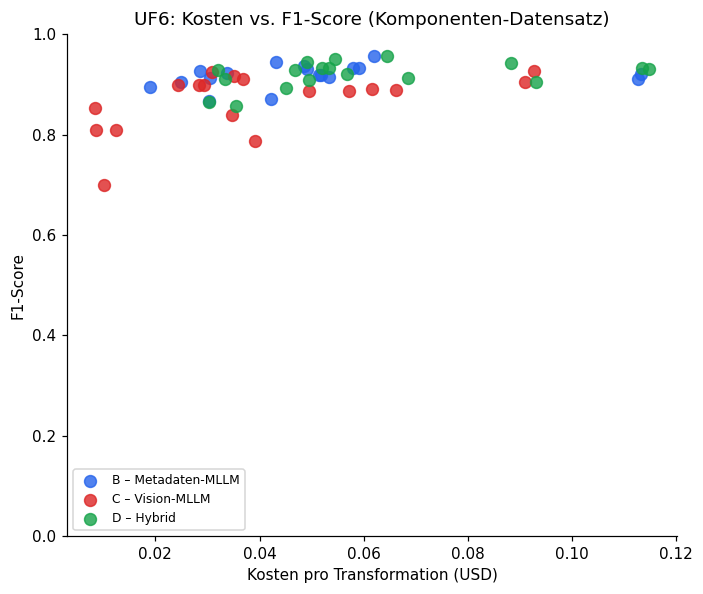

In [947]:
def cost_vs_f1(cost_df: pd.DataFrame, f1_df: pd.DataFrame) -> pd.DataFrame:
    """Joins mean cost per (approach, strategy, model, prompt_strategy) --
    the same granularity the F1 summary is already computed at -- rather
    than just broadcasting a per-strategy average across every model."""
    keys = ['approach', 'strategy', 'model', 'prompt_strategy']
    cost_agg = (cost_df[cost_df['approach'] != 'a']
                .groupby(keys, dropna=False)['cost_usd'].mean()
                .reset_index().rename(columns={'cost_usd': 'cost_usd_mean'}))
    merged = f1_df[f1_df['approach'] != 'a'].merge(cost_agg, on=keys, how='inner')
    return merged


s_cost, s_f1 = uf6_components, uf1['components']['summary']
fig, ax = plt.subplots(figsize=(6.5, 5.5))
if s_cost is not None and s_f1 is not None:
    merged = cost_vs_f1(s_cost, s_f1)
    for a, sub in merged.groupby('approach'):
        ax.scatter(sub['cost_usd_mean'], sub['f1_macro'], label=approach_label_de(a),
                   color=APPROACH_COLORS.get(a, '#999'), alpha=0.8, s=60)
ax.set_xlabel('Kosten pro Transformation (USD)')
ax.set_ylabel('F1-Score')
ax.set_ylim(0, 1)
ax.legend(fontsize=8)
ax.set_title('UF6: Kosten vs. F1-Score (Komponenten-Datensatz)')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'uf6_kosten-vs-f1_komponenten.png', dpi=150, bbox_inches='tight')
plt.show()

UI dataset, split into `pretty`/`messy`. *(Chart text in German.)*

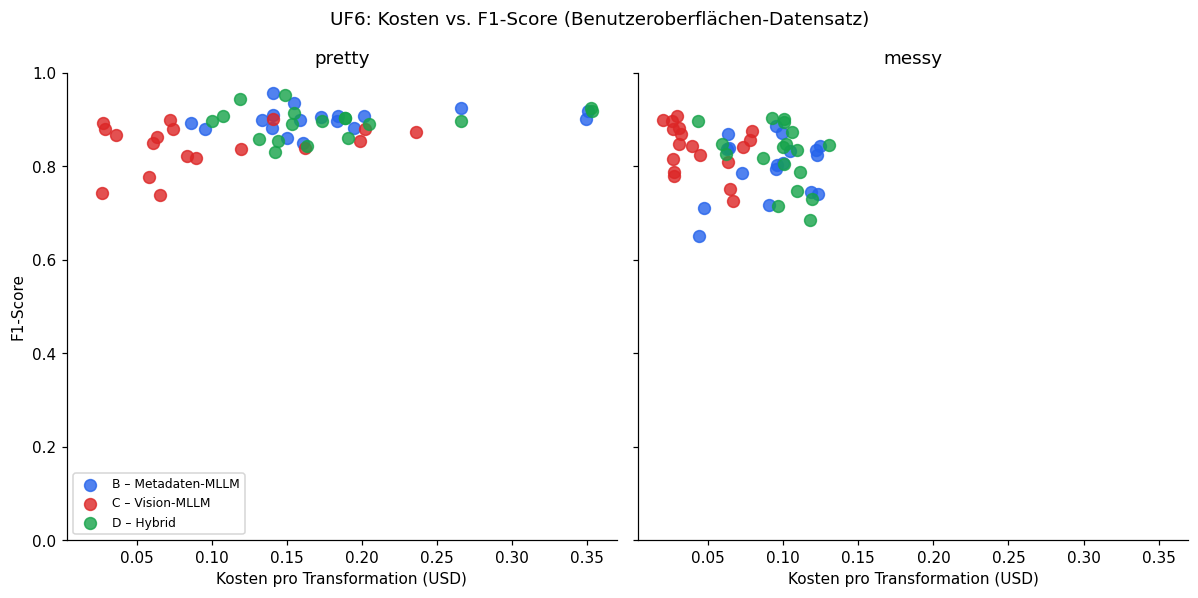

In [948]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5.5), sharex=True, sharey=True)

for ax, variant in zip(axes, ['pretty', 'messy']):
    if uf6_uis is None:
        ax.set_visible(False)
        continue
    cost_sub = uf6_uis[uf6_uis['variant'] == variant]
    f1_sub = variant_df(uf1['uis']['by_group'], variant)
    if cost_sub.empty or f1_sub is None or f1_sub.empty:
        ax.set_visible(False)
        continue
    merged = cost_vs_f1(cost_sub, f1_sub)
    for a, sub in merged.groupby('approach'):
        ax.scatter(sub['cost_usd_mean'], sub['f1_macro'], label=approach_label_de(a),
                   color=APPROACH_COLORS.get(a, '#999'), alpha=0.8, s=60)
    ax.set_xlabel('Kosten pro Transformation (USD)')
    ax.set_ylim(0, 1)
    ax.set_title(variant)

axes[0].set_ylabel('F1-Score')
axes[0].legend(fontsize=8)
fig.suptitle('UF6: Kosten vs. F1-Score (Benutzeroberfl\u00e4chen-Datensatz)')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'uf6_kosten-vs-f1_benutzeroberflaechen.png', dpi=150, bbox_inches='tight')
plt.show()